##### **SETUP & CONFIGURATION**

In [1]:
import sys
sys.path.append('../src')
import torch
import pandas as pd
import numpy as np
import data_preprocessing as data_prep
import graph
import models
import utils
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import umap
from torch_geometric.data import HeteroData
from scipy.stats           import spearmanr, mannwhitneyu
from sklearn.decomposition import PCA
from dataclasses import dataclass, field
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

c:\Users\pikachu\diploma\project_v2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
import importlib
importlib.reload(models)
importlib.reload(graph)
importlib.reload(data_prep)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\pikachu\\diploma\\project_v2\\ml\\notebooks\\../src\\utils.py'>

In [8]:
utils.clear_memory()

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent
ARTIFACT_DIR = PROJECT_DIR/"artifacts"      # ml\artifacts
ARTIFACT_DIR.mkdir(exist_ok=True)
DATA_DIR = PROJECT_DIR/"data/processed"
DATA_DIR.mkdir(exist_ok=True)

device = utils.setup_device()
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
utils.set_seed()    

GPU memory: 0.00 GB allocated  0.00 GB reserved
Device: cuda
GPU : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB
Seed fixed: 42


##### **DATA LOADING**

In [9]:
train_raw, test_raw = data_prep.load_data()

GPU memory: 0.00 GB allocated  0.00 GB reserved
GPU memory: 0.00 GB allocated  0.00 GB reserved


In [12]:
## CONSTANTS

SECONDS_PER_HOUR = 3600
SECONDS_PER_DAY  = 86400
HOURS_PER_WEEK   = 168

CAT_COLS = ['ProductCD',  'P_emaildomain',                              # 'addr1', 'addr2',
                'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 
                'M7', 'M8', 'M9', 'id_12',                              # 'DeviceType', 'DeviceInfo',                 
                'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 
                'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 
                'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 
                'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 
                'id_37', 'id_38',]

CARD_COLS = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6',]

NODE_SOURCE_COLS = [
    # card nodes
    "card1", "card2", "card3", "card4", "card5", "card6",
    # device nodes
    "DeviceInfo", "DeviceType",
    # addr nodes
    "addr1", "addr2",
]


## Features for Encoding

TARGET_ENC_COLS = [
    'P_emaildomain', 'R_emaildomain',
    'id_20', 'id_21', 'id_25', 'id_26', 'id_30', 'id_31', 'id_33',
    'card1_card2',
]

TARGET_ENC_NUM_COLS = [
    "C1", "C2", "C4", "C6", "C7", "C8",
    "C10", "C11", "C12", "C13", "C14",
]

LABEL_ENC_COLS = [
    'ProductCD',
    'id_13', 'id_14', 'id_17', 'id_18', 'id_19',
    'id_23', 'id_24', 'id_32', 'id_34',
]

M_COLS_BINARY = ["M1", "M2", "M3", "M5", "M6", "M7", "M8", "M9"]

BINARY_ID_COLS = ["id_12", "id_15", "id_16", "id_27", "id_28", "id_29",
                      "id_35", "id_36", "id_37", "id_38"]

exclude_from_num = set(CAT_COLS + NODE_SOURCE_COLS)
NUM_COLS = [c for c in train_raw.columns if c not in exclude_from_num]

prep_config = data_prep.PreprocessConfig(
    cat_cols            = CAT_COLS,
    node_source_cols    = NODE_SOURCE_COLS,
    target_enc_cols     = TARGET_ENC_COLS,
    target_enc_num_cols = TARGET_ENC_NUM_COLS,
    label_enc_cols      = LABEL_ENC_COLS,
    m_cols_binary       = M_COLS_BINARY,
    binary_id_cols      = BINARY_ID_COLS,
)

##### **DATA PREPROCESSING & FEATURE ENGINEERING**

In [18]:
train_df = data_prep.drop_leaky_features(train_raw)
train_df = train_df.sort_values("TransactionDT").reset_index(drop=True)

## Split
train_df, val_df = data_prep.temporal_split(train_df)
n_train = len(train_df)

train_df = data_prep.d_columns_transformation(train_df)
val_df = data_prep.d_columns_transformation(val_df)

## Fill Missing Values
train_df, num_fill = data_prep.fill_numeric_features(train_df, NUM_COLS)
cols_to_fill = set(CAT_COLS + NODE_SOURCE_COLS)
train_df, cat_fill = data_prep.fill_categorical_features(train_df, cols_to_fill)
val_df             = data_prep.apply_fill_values(val_df, num_fill, cat_fill)

for col in CARD_COLS:
    train_df[col] = train_df[col].astype(str)
    val_df[col]   = val_df[col].astype(str)

## Card Features 
train_df = data_prep.create_card_features(train_df, CARD_COLS)
val_df   = data_prep.create_card_features(val_df, CARD_COLS)

if "card1" in train_df.columns and "addr1" in train_df.columns:
    card_stability_map = train_df.groupby("card1")["addr1"].nunique()
    train_df["card_stability"] = (
        train_df["card1"].map(card_stability_map).fillna(1).astype("float32"))
    val_df["card_stability"] = (
        val_df["card1"].map(card_stability_map).fillna(1).astype("float32"))

## Create User_ID
train_df = data_prep.create_composite_id(
    train_df,
    # ["card1", "addr1", "P_emaildomain"],
    # ["card1", "addr1", "id_33"],
    # ["card1", "addr1", "D1"],
    ["card1", "DeviceInfo"],  
    "user_id")
val_df   = data_prep.create_composite_id(
    val_df,
    # ["card1", "addr1", "D1"],
    ["card1", "DeviceInfo"],
    "user_id")


## Create Device ID
train_df = data_prep.create_composite_id(
    train_df,
    ["DeviceInfo", "DeviceType"],
    "device_id")
val_df   = data_prep.create_composite_id(
    val_df,
    ["DeviceInfo", "DeviceType"],
    "device_id")

## Create Address ID
train_df = data_prep.create_composite_id(
    train_df,
    ["addr1", "addr2"],
    "addr_id")
val_df = data_prep.create_composite_id(
    val_df,
    ["addr1", "addr2"],
    "addr_id")

## Create Card ID
train_df = data_prep.create_composite_id(
    train_df,
    ["card1", "card2", "card3", "card5"],
    "card_id")
val_df = data_prep.create_composite_id(
    val_df,
    ["card1", "card2", "card3", "card5"],
    "card_id")


## Categorical Encoding
train_df, encoders, encoded_cols = data_prep.categorical_encoding_train(
    train_df, TARGET_ENC_COLS, TARGET_ENC_NUM_COLS, LABEL_ENC_COLS, M_COLS_BINARY, BINARY_ID_COLS, NODE_SOURCE_COLS)
val_df                           = data_prep.categorical_encoding_valtest(
    val_df, encoders)


train_df, val_df, ratio_maps = data_prep.create_amount_ratio_features(train_df, val_df)


## Log Transformation
is_missing_cols = [c for c in train_df.columns if c.endswith("_is_missing")]
card_derived = ["card_stability", "card1_fraud_rate_oof", "card1_card2"]
no_log_cols = (
    CAT_COLS + NODE_SOURCE_COLS
    + card_derived
    + encoded_cols
    + is_missing_cols
    + [c for c in train_df.columns if c.endswith("_fraud_rate")]
    + ["user_id", "device_id", "addr_id"]
    + ["TransactionID", "isFraud", "TransactionDT",]
    + ["amt_vs_user_mean", "amt_vs_card_mean"]
    + ["tx_per_day", "night_tx_ratio"]
    + ["how_sin", "how_cos", "hour_of_week",])

skew_analysis, right_log_cols, left_log_cols = data_prep.analyze_skewness(
    train_df,
    no_log_cols, 
    skew_threshold = 0.5,
    log_threshold  = 2.0,)

train_df, log_artifacts = data_prep.apply_log_transform(
    train_df,
    right_log_cols = right_log_cols,   
    left_log_cols  = left_log_cols,  
    clip_quantile  = 0.999,)

val_df, _               = data_prep.apply_log_transform(
    val_df,
    right_log_cols = log_artifacts["right_log_cols"],
    left_log_cols  = log_artifacts["left_log_cols"],
    clip_values    = log_artifacts["clip_values"],)


full_df = pd.concat([train_df, val_df]).sort_values("TransactionDT").reset_index(drop=True)

## Add Behavioral Features
full_df["dt_prev"]     = full_df.groupby("user_id")["TransactionDT"].diff().fillna(1e6)
full_df["log_dt_prev"] = np.log1p(full_df["dt_prev"]).astype("float32")
full_df["is_burst"]    = (full_df["dt_prev"] < SECONDS_PER_HOUR).astype("int8")
    
full_df = data_prep.create_time_features(full_df)
full_df = data_prep.compute_tx_count_1h(full_df)
full_df = data_prep.compute_window_features(full_df, window=86400)
full_df = data_prep.velocity(full_df)
full_df = data_prep.create_rolling_features(full_df)
full_df = data_prep.compute_amt_zscore(full_df)

## Delete Columns
full_df = full_df.drop(columns=["TransactionID", ], errors="ignore")   

## Split
full_df = full_df.sort_values("TransactionDT").reset_index(drop=True)
train_df = full_df.iloc[:n_train].copy()
val_df   = full_df.iloc[n_train:].copy()

assert len(train_df) == n_train, f"Train size changed: {len(train_df)} != {n_train}"
assert train_df["TransactionDT"].max() <= val_df["TransactionDT"].min(), \
    "Temporal order violated!"



## XGBoost Features

cat_cols = ["addr1", "addr2", "DeviceInfo", "DeviceType",
            "card1", "card2", "card3", "card4", "card5", "card6",]

drop_cols = ["user_id", "device_id", "addr_id", "card_id", "isFraud"]
X_train = train_df.drop(
    columns=[c for c in drop_cols if c in train_df.columns])
X_val     = val_df.drop(
    columns=[c for c in drop_cols if c in val_df.columns])
y_train   = train_df["isFraud"]
y_val     = val_df["isFraud"]

for col in cat_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype("category")
    if col in X_val.columns:
        X_val[col] = X_val[col].astype("category")

In [19]:
## Save Preprocessing Artifacts

# Save Datasets
train_df.to_parquet(DATA_DIR / "train_df.parquet", index=False)
val_df.to_parquet(  DATA_DIR / "val_df.parquet",   index=False)
full_df.to_parquet( DATA_DIR / "full_df.parquet",  index=False)
X_train.to_parquet(DATA_DIR / "X_train.parquet", index=False)
X_val.to_parquet(  DATA_DIR / "X_val.parquet",   index=False)
y_train.to_frame().to_parquet(DATA_DIR / "y_train.parquet", index=False)
y_val.to_frame().to_parquet(  DATA_DIR / "y_val.parquet",   index=False)


# Fill values
utils.save_artifact(
    data      = num_fill,
    save_path = str(ARTIFACT_DIR / "num_fill.pkl"),
    metadata  = {"n_cols": len(num_fill)}
)
utils.save_artifact(
    data      = cat_fill,
    save_path = str(ARTIFACT_DIR / "cat_fill.pkl"),
    metadata  = {"n_cols": len(cat_fill)}
)

# Encoders
utils.save_artifact(
    data      = encoders,
    save_path = str(ARTIFACT_DIR / "encoders.pkl"),
    metadata  = {"encoder_types": list(encoders.keys())}
)
utils.save_artifact(
    data      = encoded_cols,
    save_path = str(ARTIFACT_DIR / "encoded_cols.json"),
    metadata  = {"n_cols": len(encoded_cols)}
)

# Log transformation
utils.save_artifact(
    data      = log_artifacts,
    save_path = str(ARTIFACT_DIR / "log_artifacts.pkl"),
    metadata  = {
        "n_right_log": len(log_artifacts["right_log_cols"]),
        "n_left_log":  len(log_artifacts["left_log_cols"]),
    }
)

# Card stability map
utils.save_artifact(
    data      = card_stability_map.to_dict(),
    save_path = str(ARTIFACT_DIR / "card_stability_map.pkl"),
    metadata  = {"n_cards": len(card_stability_map)}
)

# Amount ratio maps
utils.save_artifact(
    data      = {
        "user_amt_mean": ratio_maps["user_amt_mean"].to_dict(),
        "card_amt_mean": ratio_maps["card_amt_mean"].to_dict(),
    },
    save_path = str(ARTIFACT_DIR / "ratio_maps.pkl"),
)

# Global tx per hour
global_tx_per_hour_map = (
    (full_df["TransactionDT"] // 3600)
    .value_counts()
    .to_dict()
)
global_tx_per_hour_default = float(
    (full_df["TransactionDT"] // 3600).value_counts().median()
)
utils.save_artifact(
    data      = {
        "global_tx_per_hour_map":     global_tx_per_hour_map,
        "global_tx_per_hour_default": global_tx_per_hour_default,
    },
    save_path = str(ARTIFACT_DIR / "global_tx_per_hour.pkl"),
)

# Pipeline artifacts (все разом для RealTimeFeatureEngine)
pipeline_artifacts = {
    "num_fill":                   num_fill,
    "cat_fill":                   cat_fill,
    "encoders":                   encoders,
    "log_artifacts":              log_artifacts,
    "card_stability_map":         card_stability_map.to_dict(),
    "user_amt_mean":              ratio_maps["user_amt_mean"].to_dict(),
    "card_amt_mean":              ratio_maps["card_amt_mean"].to_dict(),
    "global_tx_per_hour_map":     global_tx_per_hour_map,
    "global_tx_per_hour_default": global_tx_per_hour_default,
}
utils.save_artifact(
    data      = pipeline_artifacts,
    save_path = str(ARTIFACT_DIR / "pipeline_artifacts.pkl"),
    metadata  = {"keys": list(pipeline_artifacts.keys())}
)

# Column lists
utils.save_artifact(
    data      = {
        "NUM_COLS":        NUM_COLS,
        "CAT_COLS":        CAT_COLS,
        "NODE_SOURCE_COLS": NODE_SOURCE_COLS,
        "CARD_COLS":       CARD_COLS,
        "cat_cols":        cat_cols,        # для category dtype
        "no_log_cols":     no_log_cols,
        "encoded_cols":    encoded_cols,
    },
    save_path = str(ARTIFACT_DIR / "column_lists.json"),
)

Artifact saved: num_fill.pkl                             (0.01 MB)
Artifact saved: cat_fill.pkl                             (0.00 MB)
Artifact saved: encoders.pkl                             (2.03 MB)
Artifact saved: encoded_cols.json                        (0.00 MB)
Artifact saved: log_artifacts.pkl                        (0.01 MB)
Artifact saved: card_stability_map.pkl                   (0.12 MB)
Artifact saved: ratio_maps.pkl                           (1.18 MB)
Artifact saved: global_tx_per_hour.pkl                   (0.02 MB)
Artifact saved: pipeline_artifacts.pkl                   (3.34 MB)
Artifact saved: column_lists.json                        (0.02 MB)


##### **HGNN**

###### **Graph Diagnostics**

In [85]:
## Graph Entity Statistics
ids = ["user_id", "device_id", "card_id", "addr_id"]
for entity in ids:
    val_count = train_df[entity].value_counts()
    print(f"{entity.upper()}:")
    print(f"    Unique nodes         : {train_df[entity].nunique()}")
    print(f"    Total linked tx      : {val_count.sum():,}")
    print(f"    Avg tx per node      : {val_count.mean():.2f}")
    print(f"    Median tx per node   : {val_count.median():.2f}")
    print(f"    Max tx per node      : {val_count.max():,}")
    print(f"    Nodes with 1 tx      : {(val_count == 1).sum():,} ({(val_count == 1).mean():.1%})")
    print(f"    Nodes with >10 tx    : {(val_count > 10).sum():,}")
    print(f"    Top 10 busiest nodes:")
    print(f"{val_count.head(10)}")

USER_ID:
    Unique nodes         : 33139
    Total linked tx      : 472,432
    Avg tx per node      : 14.26
    Median tx per node   : 2.00
    Max tx per node      : 12,157
    Nodes with 1 tx      : 16,382 (49.4%)
    Nodes with >10 tx    : 4,085
    Top 10 busiest nodes:
user_id
7919_unknown     12157
9500_unknown     10407
17188_unknown     7356
15066_unknown     5277
12695_unknown     5128
12544_unknown     4834
2803_unknown      4331
12839_unknown     3726
18132_unknown     3137
15885_unknown     3023
Name: count, dtype: int64
DEVICE_ID:
    Unique nodes         : 1761
    Total linked tx      : 472,432
    Avg tx per node      : 268.27
    Median tx per node   : 4.00
    Max tx per node      : 354,758
    Nodes with 1 tx      : 470 (26.7%)
    Nodes with >10 tx    : 431
    Top 10 busiest nodes:
device_id
unknown_unknown                 354758
Windows_desktop                  39679
iOS Device_mobile                17082
MacOS_desktop                    10835
unknown_desktop   

Entity overlap / reuse:
        reuse patterns
        shared infrastructure
        account takeover signals

In [86]:
## Degree distribution quantiles
for entity in ids:
    vc_train = train_df[entity].value_counts()
    vc_val = val_df[entity].value_counts()
    print(f"{entity.upper()}:")
    print(val_count.quantile([0.5, 0.9, 0.95, 0.99]))  # max_group_size       median time gap        95% gap

USER_ID:
0.50        2.0
0.90     1449.0
0.95     6501.0
0.99    29371.0
Name: count, dtype: float64
DEVICE_ID:
0.50        2.0
0.90     1449.0
0.95     6501.0
0.99    29371.0
Name: count, dtype: float64
CARD_ID:
0.50        2.0
0.90     1449.0
0.95     6501.0
0.99    29371.0
Name: count, dtype: float64
ADDR_ID:
0.50        2.0
0.90     1449.0
0.95     6501.0
0.99    29371.0
Name: count, dtype: float64


In [31]:
## Fraud concentration by entity

for entity in ids:
    fr = train_df.groupby(entity)["isFraud"].mean()         # fraud_rate_map

    print(f"{entity.upper()}:")
    print(fr.describe())

USER_ID:
count    33139.000000
mean         0.057696
std          0.216998
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: isFraud, dtype: float64
DEVICE_ID:
count    1761.000000
mean        0.082688
std         0.220595
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: isFraud, dtype: float64
CARD_ID:
count    13749.000000
mean         0.030350
std          0.139789
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: isFraud, dtype: float64
ADDR_ID:
count    421.000000
mean       0.039911
std        0.147337
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: isFraud, dtype: float64


In [32]:
## Users Per Device
train_df.groupby("device_id")["user_id"].nunique().describe()

count    1761.000000
mean       19.739353
std       259.522117
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max      8931.000000
Name: user_id, dtype: float64

In [33]:
## Devices Per User
train_df.groupby("user_id")["device_id"].nunique().describe()

count    33139.000000
mean         1.048945
std          0.260260
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: device_id, dtype: float64

In [34]:
## Cards Per Device
train_df.groupby("device_id")["card_id"].nunique().describe()

count    1761.000000
mean       20.392391
std       277.656565
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max      9818.000000
Name: card_id, dtype: float64

In [35]:
## Temporal Threshold Analysis

sample = train_df.sort_values("TransactionDT")
dts = sample.groupby("user_id")["TransactionDT"].diff().dropna()
print(f"dt min:    {dts.min():.0f} сек")
print(f"dt median: {dts.median():.0f} сек")
print(f"dt max:    {dts.max():.0f} сек")
print(f"dt < 3600: {(dts < 3600).mean():.1%}")
print(f"dt < 86400: {(dts < 86400).mean():.1%}")

dt min:    0 сек
dt median: 8645 сек
dt max:    11929411 сек
dt < 3600: 38.1%
dt < 86400: 76.0%


In [36]:
## User Transaction Frequency Analysis

tx_per_user = train_df["user_id"].value_counts()
print(f"Users з 1 tx    : {(tx_per_user == 1).sum():,}  "
      f"({(tx_per_user == 1).mean():.1%})")
print(f"Users з 2-5 tx  : {((tx_per_user >= 2) & (tx_per_user
                                                   <= 5)).sum():,}")
print(f"Users з >5 tx   : {(tx_per_user > 5).sum():,}")
print(f"Users з >10 tx  : {(tx_per_user > 10).sum():,}")

Users з 1 tx    : 16,382  (49.4%)
Users з 2-5 tx  : 10,099
Users з >5 tx   : 6,658
Users з >10 tx  : 4,085


In [87]:
## Unknown / Cold-Start Ratio
for entity in ids:
    unknown = train_df[entity].isna().mean()
    (train_df[entity] == "unknown").mean()
    print(entity, unknown)
    

user_id 0.0
device_id 0.0
card_id 0.0
addr_id 0.0


In [38]:
## Similarity edge feasibility
train_df.groupby("device_id").size().describe()     # чи similarity graph вибухне

count      1761.000000
mean        268.274844
std        8525.429443
min           1.000000
25%           1.000000
50%           4.000000
75%          10.000000
max      354758.000000
dtype: float64

In [39]:
## Connected component intuition            # скільки transaction nodes ізольовані?
for entity in ids:
    vc = train_df[entity].value_counts()
    isolated = (vc == 1).sum()
    print(isolated)

16382
470
3890
166


###### **Build Graph**

In [7]:
# Baseline HGNN

@dataclass
class GraphConfig:
    """Конфігурація побудови графу. """

    # ── Node features ─────────────────────────────────────────
    graph_features: list = field(default_factory=lambda: [          # # фокусуються на behavioral patterns (velocity, burst),
        "log_dt_prev", 
        # "TransactionAmt",                     # "TransactionAmt_orig",
        "is_burst", "amt_ratio_mean",  "amt_diff_mean", "hour_sin", "card1_freq",     
        # "amt_zscore",         # ✅ є — compute_amt_zscore - те саме   "amt_ratio_mean",  "amt_diff_mean",
        "amt_vs_user_mean",   # ✅ є — create_amount_ratio_features
        "amt_vs_card_mean",   # ✅ є — create_amount_ratio_features
        # "tx_per_day", #  
        # "night_tx_ratio",     
        # "how_sin",             #  
        # "how_cos",
        # "global_tx_per_hour",# 

        # # ── Velocity ────────!!!!!!!!!!──────────────────────────────────
        # "tx_count_1h",        # ✅ є — compute_tx_count_1h   (−0.0084)
        # "tx_count_24h",       # ✅ є — compute_window_features   NOISE
        # "amt_sum_24h",        # ✅ є — compute_window_features     NOISE
        # "amt_mean_24h",       # ✅ є — compute_window_features     

        "card1_fraud_rate",   # OOF fraud rate per card
        #"card2_fraud_rate",      # ~500 unique
        # "card3_fraud_rate",      # ~114 unique
        # "card5_fraud_rate",      # ~119 unique
        
        "DeviceInfo_fraud_rate",  # fraud rate per device
        "addr1_fraud_rate",       # fraud rate per address
        "card_stability",         # унікальних addr1 per card1

        # ── пропускаємо низьку кардинальність ─────────────────
        # "card4_fraud_rate",    # 4 unique — шум
        # "card6_fraud_rate",    # 4 unique — шум
        # "DeviceType_fraud_rate", # 2 unique — шум
        # "addr2_fraud_rate",    # ~60 unique — можна спробувати
    ])

    
    entity_cols: list = field(default_factory=lambda: [
        # "user_id", "addr_id",      # -0.63 + overfitting # "device_id", 
        # "user_id", "device_id", "addr_id", "ProductCD"             # "card3", "P_emaildomain" - overfit
        "user_id", "device_id", "addr_id", "card_id"         # "R_emaildomain" noise,  "ProductCD"
    ])
    # entity_feat_cols: list = field(default_factory=lambda: [
    #     "log_total_tx", "amt_mean", "amt_std",
    #     "unique_devices_per_user", "unique_users_per_device",
    #     "device_reuse_ratio", "time_span", "fraud_rate_oof",

    #     # # ✅ нові
    #     "amt_max",          # аномально велика транзакція          !!! Якщо важливо мінімізувати false positives
    #     "amt_min",          # card testing (мала сума)              !!! топ в комбинації х мах
    #     "tx_per_day",       # частота транзакцій
    #     "night_tx_ratio",   # частка нічних                   -
    #     # "burst_ratio",      # частка burst     дублікат

    #     # "tx_velocity", # "log_tx_count",   - noise
    # ])

    entity_features: dict = field(default_factory=dict, repr=False)
    entity_feat_cols_dict: dict = field(default_factory=lambda: {
        "user_id": [
            "log_total_tx",           # активність
            "amt_mean", "amt_std",    # поведінка сум
            "amt_max", "amt_min",     # аномалії
            "unique_devices_per_user", # скільки пристроїв
            # "device_reuse_ratio",      # підозрілі пристрої   Recall down
            "time_span",               # тривалість активності
            "fraud_rate_oof",          # OOF fraud rate
            # "tx_per_day",              # частота              Recall down
            # "night_tx_ratio",          # нічна активність     Recall down
        ],
        "device_id": [
            "log_total_tx",
            "amt_mean", "amt_std",
            "amt_max", "amt_min",
            "unique_users_per_device", # скільки користувачів
            # "device_reuse_ratio",      # перевикористання        Recall Down
            "time_span",
            "fraud_rate_oof",
            # "night_tx_ratio",          # нічні транзакції з пристрою  noise
        ],
        "addr_id": [
            "log_total_tx",
            "amt_mean", "amt_std",
            "amt_max", "amt_min",
            "time_span",
            "fraud_rate_oof",
            # "unique_devices_per_user", # скільки пристроїв з адреси   NOISE
        ],
        "card_id": [
            "log_total_tx",
            "amt_mean", "amt_std",
            "amt_max", "amt_min",
            "time_span",
            "fraud_rate_oof",
            # "tx_per_day",
            # "unique_devices_per_user", # скільки пристроїв по картці noise
        ],
    })
    
    # @property
    # def entity_feat_dim(self) -> int:
    #     return len(self.entity_feat_cols)

    # ── Edge weights ──────────────────────────────────────────
    # edge_weight_type: str = "inv_freq"   # "fraud_rate"   # "fraud_rate" | "inv_freq" | "uniform"

    # ── Edge attr ─────────────────────────────────────────────
    # edge_attr = [freq_weight, fraud_rate, temporal_decay]
    # edge_dim  = 3
    # GATv2Conv навчає важливість кожного компонента через attention
    edge_attr_dim: int = 3  #


    # ── Temporal edges ────────────────────────────────────────
    temporal_enabled:   bool  = True
    #  temporal_threshold: int   = 3600       # секунди BASE
    temporal_threshold:  float = 3600.0   # ✅ fallback якщо не в temporal_thresholds
    temporal_thresholds: dict = field(default_factory=lambda: {
        "user_id":   3600,    # 1h  → burst fraud
        "device_id": 5400,  # 3600, #  ,     # 10800,   # 3h  → median dt  median ≈ 2.4h   
        "card1":     21600,    # 43200, # 86400,   # 1d  → behavioral pattern   
    })
    temporal_group_cols: list = field(default_factory=lambda: [
        "user_id", "device_id",
        "card1",    # ✅ TX-TX по картці)    
    ])
    max_temporal_neighbors:  int   = 1   # 2 BAD   # 1     # ✅ нове поле: 1=поточна, 3=top-k  2  

    #----------------------------
    similarity_enabled:   bool = True  # ✅ нове
    # similarity_cols:      list = field(default_factory=lambda: [
    #     # "device_id",  # same device → connect
    #     # "card1",      # same card → connect
    #     "card_id"
    # ])
    # similarity_max_edges: int = 5  # максимум сусідів на вузол

    similarity_configs: list = field(default_factory=lambda: [
        # ── Amount similarity ─────────────────────────────────
    #     {                                                             #   BAD
    #     "edge_type":         "sim_amount_card",
    #     "group_col":         "card1",                                             # "card_id",
    #     "amount_col":        "amt_vs_user_mean",
    #     "time_col":          "TransactionDT",
    #     "max_neighbors":     1,     # 3,
    #     "max_group_size":    100,     # 500,
    #     "max_time_diff":     3600,   # 86400,
    #     "amt_sim_threshold": 0.5,
    #     "sort_by_amount":    True,   # ✅ сортуємо по сумі
    # },

    {                                                       
        "edge_type":         "sim_amount_device",
        "group_col":         "device_id",
        "amount_col":        "amt_vs_user_mean",
        "time_col":          "TransactionDT",
        "max_neighbors":     1,   # 2, #  1,     #  3,
        "max_group_size":    200, #  300, # 100, #   BEST 200!,   # 500,  
        "max_time_diff":     3600,                  # 7200, #    1800     # 86400,
        "amt_sim_threshold": 0.5, #  0.6, # 0.5,
        "sort_by_amount":    True,
    },

    # # ── Velocity similarity ────────────────────────────────   

    # { 
    #     "edge_type":         "sim_velocity_card",
    #     "group_col":         "card_id",
    #     "amount_col":        "log_dt_prev",
    #     "time_col":          "TransactionDT",
    #     "max_neighbors":     3,
    #     "max_group_size":    500,
    #     "max_time_diff":     3600,
    #     "amt_sim_threshold": 0.3,
    #     "sort_by_amount":    False,  # ✅ сортуємо по часу
    # },
    {                                                             
        "edge_type":         "sim_velocity_device",
        "group_col":         "device_id",
        "amount_col":        "log_dt_prev",
        "time_col":          "TransactionDT",
        "max_neighbors":     1,     # 2,BAD   #1,     # 3,
        "max_group_size":    100,    # 500,
        "max_time_diff":     1800, #   1200,  # 3600,   
        "amt_sim_threshold": 0.15,  # 0.25,   #  # 0.2,    # 0.3,      
        "sort_by_amount":    False,
    },

##############################################################################
    # # ── Burst similarity ───────────────────────────────────
    # {
    #     "edge_type":         "sim_burst_card",
    #     "group_col":         "card_id",
    #     "amount_col":        "is_burst",
    #     "time_col":          "TransactionDT",
    #     "max_neighbors":     3,
    #     "max_group_size":    500,
    #     "max_time_diff":     3600,
    #     "amt_sim_threshold": 0.0,    # ← бінарний
    #     "sort_by_amount":    False,
    # },
#     {
#         "edge_type":         "sim_burst_device",
#         "group_col":         "device_id",
#         "amount_col":        "is_burst",
#         "time_col":          "TransactionDT",
#         "max_neighbors":     1,   # 3,
#         "max_group_size":    100, #  500,
#         "max_time_diff":     3600,
#         "amt_sim_threshold": 0.0,
#         "sort_by_amount":    False,
#     },
])

    # ── Normalization ─────────────────────────────────────────
    # ✅ column normalization (opt-ml 2024)
    node_norm: str = "standard_scaler"    # "standard_scaler" | "degree" | "none"

    # ── Артефакти після build_graph ───────────────────────────
    # ✅ зберігаються після першого виклику build_graph
    # при повторному виклику — використовуються як є (no refit)
    feat_scaler:     object = field(default=None, repr=False)
    # entity_features: dict   = field(default_factory=dict, repr=False)
    entity_scalers:  dict   = field(default_factory=dict, repr=False)
    num_nodes_dict:  dict   = field(default_factory=dict, repr=False)
    val_to_idx_dict: dict   = field(default_factory=dict, repr=False)


@dataclass
class ModelConfig:
    """Конфігурація архітектури HGNN."""
    # hidden_dim:    int   = 128 # 64   # 128   # 64       # 128 overfit
    hidden_dim:    int   = 64 
    heads:         int   = 4
    dropout:       float = 0.6   #  0.6   #  0.5      # 0.3 overfit
    num_layers:    int   = 2              # 3
    num_layers:    int   = 2
    aggr:          str   = "mean"         # "mean" | "sum" | "max"



@dataclass
class TrainConfig:
    """Конфігурація тренування."""
    # ── Оптимізатор ───────────────────────────────────────────
    lr:           float = 3e-5  #   1e-5   #              # 1e-3  3e-4  3e-5, 5e-4
    weight_decay: float = 1e-4  # 1e-4   
    optimizer:    str   = "adamw"         # "adam" | "adamw"

    # ── Loss ──────────────────────────────────────────────────
    loss_type:    str   = "focal"           # "bce" | "focal"
    focal_alpha:  float = 0.25             # 0.25   0.75 (for imbalanced batch)
    focal_gamma:  float = 2.0
    # ✅ FIX 1: pos_weight=1.0 якщо ImbalancedSampler увімкнений
    # Якщо use_imbalanced_sampler=False → pos_weight обчислюється з даних (~28)
    # Якщо use_imbalanced_sampler=True  → pos_weight=1.0 (sampler вже балансує)
    pos_weight_override: float = 1.0  #    None    1.0    5.0 

    lp_weight:    float = 0.1  # 0.2   # 0.25   #    # 0.05 #  0.1 # 0.05 # 0.0    # 0.01            # link prediction loss weight

    # ── Scheduler ─────────────────────────────────────────────
    epochs_phase1: int  = 10   #     60 # 50
    epochs_phase2: int  = 0
    t0_cosine:     int  = 20 # 10
    t_mult:        int  = 2
    plateau_factor: float = 0.5
    plateau_patience: int = 8

    # ── Loader ────────────────────────────────────────────────
    batch_size_train: int = 2048   # 1024
    batch_size_val:   int = 4096   # 2048
    # num_neighbors:    list = field(default_factory=lambda: [15, 10, 5])     # [15, 10]   #[10, 5]
    num_neighbors:    list = field(default_factory=lambda: [15, 10])     # [15, 10]   #[10, 5]
    use_imbalanced_sampler: bool = True    # False

    # ── Early stopping ────────────────────────────────────────
    early_stopping_patience: int = 20   # 10 # 15     

 # ✅ FIX 2: метрика для best model і early stopping
    monitor_metric: str = "pr_auc"   # "roc_auc" | "pr_auc" | "val_loss"

In [8]:
utils.clear_memory()

graph_config = GraphConfig()
model_config = ModelConfig()
train_config = TrainConfig()

missing = [f for f in graph_config.graph_features if f not in full_df.columns]
print(f"Missing graph features: {missing}")

## Build Graph
with utils.timer("Build Graph"):
    base_graph = graph.build_graph(
        train_df, val_df, graph_config)

# Graph Validation
graph.validate_graph_and_loader(base_graph, train_config, y_train=y_train)
graph.validate_fraud_ratio(base_graph, train_config, y_train)

GPU memory: 0.00 GB allocated  0.00 GB reserved
Missing graph features: []
✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1

np.float64(0.500830078125)

###### **Train HGNN**

In [9]:
with utils.timer("Train HGNN"):
    model, gnn_artifacts = graph.train_gnn(
        base_graph, 
        y_train, 
        device, 
        train_config, 
        model_config, 
        graph_config)

# train_emb    = gnn_artifacts["train_emb"]
# val_emb      = gnn_artifacts["val_emb"]
# train_gnn_logits = gnn_artifacts["train_logits"]
# val_gnn_logits   = gnn_artifacts["val_logits"]

# ── Розпакування артефактів ───────────────────────────────────
train_emb        = gnn_artifacts["train_emb"]         # semantic (для SHAP)
val_emb          = gnn_artifacts["val_emb"]
train_emb_graph  = gnn_artifacts["train_emb_graph"]   # graph proj (для XGBoost)
val_emb_graph    = gnn_artifacts["val_emb_graph"]
train_gnn_logits = gnn_artifacts["train_logits"]
val_gnn_logits   = gnn_artifacts["val_logits"]

## Metrics
val_gnn_probas = torch.sigmoid(torch.tensor(val_gnn_logits)).numpy()
gnn_metrics = models.compute_metrics(val_gnn_probas, y_val)

print(f"graph_features: {len(graph_config.graph_features)}")  
utils.clear_memory()
                                          

✅ Seed fixed: 42
  PHASE 1 — CosineAnnealingWarmRestarts  (10 epochs)
─────────────────────────────────────────────────────────────────
   Ep |    Train |  ValLoss |  ROC-AUC |  PR-AUC |        LR
─────────────────────────────────────────────────────────────────
     0 |   0.2770 |   0.0505 |   0.7352 |  0.1563 |  0.000030 ✅
     1 |   0.1733 |   0.0475 |   0.7385 |  0.1582 |  0.000030 ✅
     2 |   0.1644 |   0.0478 |   0.7420 |  0.1588 |  0.000029 ✅
     3 |   0.1590 |   0.0481 |   0.7439 |  0.1622 |  0.000028 ✅
     4 |   0.1553 |   0.0465 |   0.7433 |  0.1611 |  0.000027
     5 |   0.1526 |   0.0458 |   0.7459 |  0.1617 |  0.000026
     6 |   0.1503 |   0.0463 |   0.7452 |  0.1636 |  0.000025 ✅
     7 |   0.1493 |   0.0453 |   0.7453 |  0.1612 |  0.000023
     8 |   0.1480 |   0.0463 |   0.7464 |  0.1633 |  0.000022
     9 |   0.1470 |   0.0445 |   0.7470 |  0.1637 |  0.000020 ✅

 Phase 1 best restored (pr_auc=0.1637)

═══════════════════════════════════════════════════════
  PHASE 

In [ ]:

# L2-нормалізовані embeddings
def normalize_embeddings(
        emb,
):
    """
    L2-нормалізація embeddings перед використанням.
    Cosine similarity стає dot product — краще для downstream tasks.
    """
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-8)
    emb_normalized = emb / norms

    return emb_normalized

def feature_importance(
        xgb_model,
        X_train:       pd.DataFrame,
        hgnn_model     = None,   # HGNN model для per-stream breakdown
        top_n:         int = 15,
) -> pd.Series:
    """
    Feature importance for XGBoost with HGNN embeddings.
    """
    imp = pd.Series(
        xgb_model.feature_importances_,
        index=X_train.columns,
    ).sort_values(ascending=False)

    # ── Загальний топ ─────────────────────────────────────────
    print(f"Feature importance TOP {top_n}:")
    print(imp.head(top_n).to_string())

    # ── GNN embedding importance ──────────────────────────────
    emb_imp = imp[imp.index.str.startswith("gnn_")]
    if len(emb_imp) > 0:
        print(f"\nEmbedding importance TOP {min(top_n, len(emb_imp))}:")
        print(emb_imp.head(top_n).to_string())
        print(f"\nTotal GNN importance: {emb_imp.sum():.4f} "
              f"({emb_imp.sum() / imp.sum() * 100:.1f}% of total)")
    else:
        print("\n[WARN]  No GNN embedding in X_train")

    # ── Per-stream breakdown (якщо є hgnn_model) ──────────────
    if hgnn_model is not None and hasattr(hgnn_model, "stream_names"):
        print(f"\nPer-stream importance:")
        stream_imp = {}
        for stream in hgnn_model.stream_names:
            cols       = [c for c in emb_imp.index
                         if c.startswith(f"gnn_{stream}_")]
            valid_cols = [c for c in cols if c in imp.index]
            total      = imp[valid_cols].sum() if valid_cols else 0.0
            stream_imp[stream] = total

        for stream, total in sorted(
            stream_imp.items(), key=lambda x: x[1], reverse=True
        ):
            pct = total / imp.sum() * 100 if imp.sum() > 0 else 0
            print(f"  {stream:<30}: {total:.4f}  ({pct:.1f}%)")

    return imp

###### **Graph Features Analysis**

In [12]:
# Embedding have signal or not
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

def analyze_embedding_quality(train_emb, val_emb, y_train, y_val):

    # 1. Cosine similarity між центроїдами
    fraud_emb = train_emb[y_train == 1]
    legit_emb = train_emb[y_train == 0]
    fraud_mean = fraud_emb.mean(axis=0)
    legit_mean = legit_emb.mean(axis=0)
    cos_sim = np.dot(fraud_mean, legit_mean) / (
        np.linalg.norm(fraud_mean) * np.linalg.norm(legit_mean) + 1e-8
    )

    fraud_std = fraud_emb.std(axis=0).mean()
    legit_std = legit_emb.std(axis=0).mean()

    lr = LogisticRegression(max_iter=1000, class_weight="balanced")
    lr.fit(train_emb, y_train)
    p = lr.predict_proba(val_emb)[:, 1]
    lr_pr_auc = average_precision_score(y_val, p)

    print(f"Fraud centroid vs Legit centroid cosine similarity: {cos_sim:.4f}")
    print(f"Fraud emb std:  {fraud_std:.4f}")
    print(f"Legit emb std:  {legit_std:.4f}")
    print()
    print("Emb-only ROC-AUC:", roc_auc_score(y_val, p))
    print(f"LogReg PR-AUC: {lr_pr_auc:.4f}")
    return cos_sim, lr_pr_auc

print("Semantic embeddings")
cos_sim, lr_pr_auc = analyze_embedding_quality(train_emb, val_emb, y_train, y_val)

print("\nGraph projection (для XGBoost)")
cos_sim_g, lr_pr_g = analyze_embedding_quality(
    train_emb_graph, val_emb_graph,
    y_train.values, y_val.values,
)

Semantic embeddings
Fraud centroid vs Legit centroid cosine similarity: 0.9714
Fraud emb std:  0.3097
Legit emb std:  0.2363

Emb-only ROC-AUC: 0.7327791247237907
LogReg PR-AUC: 0.1433

Graph projection (для XGBoost)
Fraud centroid vs Legit centroid cosine similarity: 0.7083
Fraud emb std:  0.9041
Legit emb std:  0.9794

Emb-only ROC-AUC: 0.7469962855543806
LogReg PR-AUC: 0.1230


##### **XGBOOST BASELINE**

In [8]:
params = {
    # ── Tree structure ────────────────────────────────────────
    "n_estimators":     2000,
    "max_depth":        6,          # 4-8: менше → менше overfit
    "min_child_weight": 5,  # 1,          # більше → менше overfit (спробуй 5-10)
    "max_delta_step":   1,   # 0,          # 1-10 корисно для imbalanced

    # ── Sampling ──────────────────────────────────────────────
    "subsample":          0.8,      # 0.6-0.9
    "colsample_bytree":   0.8,      # 0.6-0.9
    "colsample_bylevel":  0.8,   # 1.0,      # 0.6-1.0 — додаткова регуляризація
    "colsample_bynode":   0.8,     # 1.0,      # 0.6-1.0

    # ── Learning ──────────────────────────────────────────────
    "learning_rate":  0.02,         # 0.01-0.05
    "gamma":          0.1, #  0.0,          # min split loss, 0-5
    "reg_alpha":      0.1,   # 0.0,          # L1, спробуй 0.1-1.0
    "reg_lambda":     5.0,     # 1.0,          # L2, спробуй 1.0-10.0

    # ── Imbalance ─────────────────────────────────────────────
    # scale_pos_weight обчислюється в train_xgboost автоматично
    # варіанти:
    #   n_neg / n_pos        ≈ 27.5  — стандартний
    #   sqrt(n_neg / n_pos)  ≈ 5.2   — м'якший, менше overfit на fraud
    #   1.0                           — без компенсації (якщо imbalanced sampler)
    "spw_mode": "sqrt",             # "full" | "sqrt" | "none"

    # ── Training ──────────────────────────────────────────────
    "early_stopping_rounds": 100,
}

In [9]:
with utils.timer("Tabular baseline - XGBoost train"):
    base_xgb, base_xgb_probas = models.train_xgboost(
        X_train, y_train, X_val, y_val, params
    )

base_xgb_metrics = models.compute_metrics(base_xgb_probas, y_val)

[0]	validation_0-aucpr:0.13605
[100]	validation_0-aucpr:0.47097
[200]	validation_0-aucpr:0.50201
[300]	validation_0-aucpr:0.52239
[400]	validation_0-aucpr:0.53622
[500]	validation_0-aucpr:0.54509
[600]	validation_0-aucpr:0.55147
[700]	validation_0-aucpr:0.55716
[800]	validation_0-aucpr:0.56213
[900]	validation_0-aucpr:0.56661
[1000]	validation_0-aucpr:0.57080
[1100]	validation_0-aucpr:0.57305
[1200]	validation_0-aucpr:0.57473
[1300]	validation_0-aucpr:0.57698
[1400]	validation_0-aucpr:0.57932
[1500]	validation_0-aucpr:0.58148
[1600]	validation_0-aucpr:0.58384
[1700]	validation_0-aucpr:0.58496
[1800]	validation_0-aucpr:0.58615
[1900]	validation_0-aucpr:0.58744
[1999]	validation_0-aucpr:0.58950
⏱  Tabular baseline - XGBoost train: 19m 60.0s
Metric                  Value
------------------------------------------------------------------------
ROC-AUC                0.9135
PR-AUC                 0.5895
Best threshold         0.5426
F1                     0.5840
Precision              0.688

In [10]:
## Feature Importance (Baseline Model)

df_imp = models.analyze_feature_importance(
    xgb_model       = base_xgb,
    X_train         = X_train,
    hgnn_model      = None,
    top_n           = 30,
    importance_type = "gain",
    drop_threshold  = 0.0001,
)

Feature Importance TOP 30 (gain)
Feature                             Type                 Imp     Pct    Cum%
────────────────────────────────────────────────────────────────────────────────────────────────────
  V258                              V_feature       5644.6797  13.08%   13.1%
  V218                              V_feature       4520.4121  10.47%   23.6%
  V294                              V_feature       1565.7539   3.63%   27.2%
  C4                                C_feature       1450.4355   3.36%   30.5%
  V295                              V_feature       1443.4425   3.34%   33.9%
  V219                              V_feature       1080.6501   2.50%   36.4%
  V187                              V_feature       1032.9137   2.39%   38.8%
  V265                              V_feature       956.1384   2.22%   41.0%
  V257                              V_feature       826.3771   1.91%   42.9%
  C8                                C_feature       808.3013   1.87%   44.8%
  V91       

In [11]:
## Get Features to drop

drop_cols_dict = models.get_features_to_drop(df_imp)

In [12]:
drop_cols = drop_cols_dict["all"]

X_train_cleaned = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_val_cleand   = X_val.drop(  columns=[c for c in drop_cols if c in X_val.columns])

print(f"Dropped: {len(drop_cols)} columns")

assert X_train.shape[1] == X_val.shape[1]

Dropped: 379 columns


In [ ]:
## Save Artifacts
X_train_cleaned.to_parquet(DATA_DIR / "X_train_cleaned.parquet", index=False)
X_val_cleand.to_parquet(   DATA_DIR / "X_val_cleaned.parquet",   index=False)

In [19]:
with utils.timer("Tabular baseline - XGBoost train"):
    base_xgb_cleaned, base_xgb_probas = models.train_xgboost(
        X_train_cleaned, y_train, X_val_cleand, y_val, params
    )

base_xgb_cleaned_metrics = models.compute_metrics(base_xgb_probas, y_val)

[0]	validation_0-aucpr:0.14825
[100]	validation_0-aucpr:0.46875
[200]	validation_0-aucpr:0.49899
[300]	validation_0-aucpr:0.52054
[400]	validation_0-aucpr:0.53583
[500]	validation_0-aucpr:0.54510
[600]	validation_0-aucpr:0.55196
[700]	validation_0-aucpr:0.55728
[800]	validation_0-aucpr:0.56275
[900]	validation_0-aucpr:0.56722
[1000]	validation_0-aucpr:0.57058
[1100]	validation_0-aucpr:0.57361
[1200]	validation_0-aucpr:0.57615
[1300]	validation_0-aucpr:0.57822
[1400]	validation_0-aucpr:0.57935
[1500]	validation_0-aucpr:0.58062
[1600]	validation_0-aucpr:0.58184
[1700]	validation_0-aucpr:0.58370
[1800]	validation_0-aucpr:0.58543
[1900]	validation_0-aucpr:0.58749
[1999]	validation_0-aucpr:0.58898
⏱  Tabular baseline - XGBoost train: 3m 22.3s
Metric                  Value
------------------------------------------------------------------------
ROC-AUC                0.9133
PR-AUC                 0.5888
Best threshold         0.5542
F1                     0.5828
Precision              0.7033

In [20]:
## Save XGBoost Artefacts
utils.save_artifact(
    data      = drop_cols_dict["all"],
    save_path = str(ARTIFACT_DIR / "zero_importance_features.json"),
    metadata  = {"model": "base_xgb", "n_features": len(X_train.columns)},
)




Artifact saved: zero_importance_features.json            (0.01 MB)


##### **XGBOOST BASELINE + HGNN EMBEDDINGS**

In [ ]:
def prepare_dataset(X_train, X_val, train_emb, val_emb, emb_cols):
    X_train = X_train.copy()
    X_val = X_val.copy()

    X_train = X_train.reset_index(drop=True)
    X_val   = X_val.reset_index(drop=True)

    assert len(train_emb) == len(X_train), \
        f"Train embeddings mismatch: {len(train_emb)} != {len(X_train)}"
    assert len(val_emb) == len(X_val), \
        f"Val embeddings mismatch: {len(val_emb)} != {len(X_val)}"

    assert not np.isnan(train_emb).any(), "NaN в train embeddings!"
    assert not np.isnan(val_emb).any(),   "NaN в val embeddings!"
    assert not np.isinf(train_emb).any(), "Inf в train embeddings!"
    assert not np.isinf(val_emb).any(),   "Inf в val embeddings!"

    train_emb_df = pd.DataFrame(
        train_emb, columns=emb_cols, index=X_train.index
    )
    val_emb_df = pd.DataFrame(
        val_emb, columns=emb_cols, index=X_val.index
    )

    X_train_gnn = pd.concat([X_train, train_emb_df], axis=1)
    X_val_gnn   = pd.concat([X_val,   val_emb_df],   axis=1)

    assert X_train_gnn.shape == (len(X_train), X_train.shape[1] + len(emb_cols)), \
        f"X_train_gnn shape mismatch: {X_train_gnn.shape}"
    assert X_val_gnn.shape == (len(X_val), X_val.shape[1] + len(emb_cols)), \
        f"X_val_gnn shape mismatch: {X_val_gnn.shape}"

    assert not X_train_gnn[emb_cols].isna().any().any(), \
        "NaN в embedding колонках X_train_gnn!"
    assert not X_val_gnn[emb_cols].isna().any().any(), \
        "NaN в embedding колонках X_val_gnn!"

    return X_train_gnn, X_val_gnn



In [ ]:
# RAW EMBEDDINGS - COMPACT COLS

# emb_cols = [f"gnn_{i}" for i in range(train_emb.shape[1])]
_, emb_cols = graph.get_embedding_col_names(model)

# X_train_gnn_raw, X_val_gnn_raw = prepare_dataset(X_train, X_val, train_emb_graph, val_emb_graph, emb_cols)
X_train_gnn_raw, X_val_gnn_raw = prepare_dataset(X_train_cleaned, X_val_cleand, train_emb_graph, val_emb_graph, emb_cols)

# Train
with utils.timer("XGB + HGNN Embeddings (raw)"):
    xgb_gnn_raw_model, xgb_gnn_raw_probs = models.train_xgboost(
        X_train_gnn_raw, y_train, X_val_gnn_raw, y_val, params
    )

# Metrics
xgb_gnn_raw_metrics = models.compute_metrics(xgb_gnn_raw_probs, y_val)     
utils.clear_memory()

[0]	validation_0-aucpr:0.15210
[100]	validation_0-aucpr:0.46381
[200]	validation_0-aucpr:0.49310
[300]	validation_0-aucpr:0.51396
[400]	validation_0-aucpr:0.52951
[500]	validation_0-aucpr:0.53870
[600]	validation_0-aucpr:0.54657
[700]	validation_0-aucpr:0.55189
[800]	validation_0-aucpr:0.55689
[900]	validation_0-aucpr:0.56091
[1000]	validation_0-aucpr:0.56453
[1100]	validation_0-aucpr:0.56741
[1200]	validation_0-aucpr:0.57026
[1300]	validation_0-aucpr:0.57201
[1400]	validation_0-aucpr:0.57331
[1500]	validation_0-aucpr:0.57405
[1600]	validation_0-aucpr:0.57530
[1700]	validation_0-aucpr:0.57656
[1800]	validation_0-aucpr:0.57787
[1900]	validation_0-aucpr:0.57937
[1999]	validation_0-aucpr:0.58019
⏱  XGB + HGNN Embeddings (raw): 3m 46.0s
Metric                  Value
------------------------------------------------------------------------
ROC-AUC                0.9132
PR-AUC                 0.5803
Best threshold         0.5109
F1                     0.5700
Precision              0.6549
Reca

In [28]:
# Feature importance SEMANTIC

semantic_cols, _ = graph.get_embedding_col_names(model)
X_train_semantic, X_val_semantic = prepare_dataset(
    X_train_cleaned, X_val_cleand,
    train_emb, val_emb,   # ← semantic
    semantic_cols,
)

xgb_semantic, _ = models.train_xgboost(
    X_train_semantic, y_train,
    X_val_semantic, y_val, params
)
imp_semantic = models.analyze_feature_importance(
    xgb_model  = xgb_semantic,
    X_train    = X_train_semantic,
    hgnn_model = model,  
)

[0]	validation_0-aucpr:0.12719
[100]	validation_0-aucpr:0.44406
[200]	validation_0-aucpr:0.48400
[300]	validation_0-aucpr:0.50856
[400]	validation_0-aucpr:0.52306
[500]	validation_0-aucpr:0.53279
[600]	validation_0-aucpr:0.54017
[700]	validation_0-aucpr:0.54724
[800]	validation_0-aucpr:0.55245
[900]	validation_0-aucpr:0.55752
[1000]	validation_0-aucpr:0.55993
[1100]	validation_0-aucpr:0.56298
[1200]	validation_0-aucpr:0.56533
[1300]	validation_0-aucpr:0.56777
[1400]	validation_0-aucpr:0.56988
[1500]	validation_0-aucpr:0.57082
[1600]	validation_0-aucpr:0.57260
[1700]	validation_0-aucpr:0.57385
[1800]	validation_0-aucpr:0.57460
[1900]	validation_0-aucpr:0.57554
[1999]	validation_0-aucpr:0.57683
Feature Importance TOP 30 (gain)
Feature                             Type                 Imp     Pct    Cum%
────────────────────────────────────────────────────────────────────────────────────────────────────
  V258                              V_feature       4570.3633   7.93%    7.9%
  gnn_ent

In [ ]:
def plot_embedding_heatmap(
    corr_matrix:   np.ndarray,
    feature_names: list,
    top_k:         int = 30,
) -> None:
    n_pcs = corr_matrix.shape[0]

    max_corr_per_feature = corr_matrix.max(axis=0)
    top_idx              = np.argsort(max_corr_per_feature)[-top_k:]

    plt.figure(figsize=(18, max(4, n_pcs * 0.5 + 1)))
    sns.heatmap(
        corr_matrix[:, top_idx],
        xticklabels = [feature_names[i] for i in top_idx],
        yticklabels = [f"PC{i}" for i in range(n_pcs)],
        cmap        = "YlOrRd",
        annot       = True,
        fmt         = ".2f",
        vmin        = 0,
        vmax        = 1,
    )
    plt.title("Embedding PCs vs Tabular Features (Spearman |r|)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    max_overall = corr_matrix.max()
    if max_overall < 0.3:
        print("Unique Embeddings")
    elif max_overall < 0.7:
        print(" Partialy duplicate tabular features")
    else:
        print("[WARN] GNN dublicate tabular features")


def diagnose_embeddings_and_graph(
    train_emb:        np.ndarray,
    train_gnn_logits: np.ndarray,
    val_emb:          np.ndarray,
    val_gnn_logits:   np.ndarray,
    y_train,
    y_val,
    X_train:          pd.DataFrame,
    data:             HeteroData,
    val_xgb_logits:   np.ndarray = None,
) -> dict:
    y_tr = np.array(y_train)
    y_vl = np.array(y_val)

    X_tr_np       = (
        X_train
        .select_dtypes(exclude=["object", "category"])
        .fillna(0)
        .values
        .astype(np.float32)
    )
    feature_names = (
        X_train
        .select_dtypes(exclude=["object", "category"])
        .columns
        .tolist()
    )

    # Basic Stats
    print("\n Embedding Basic Stats")
    print(f"  Shape      : {train_emb.shape}")
    print(f"  Mean       : {train_emb.mean():.4f}  (✓~0)")
    print(f"  Std        : {train_emb.std():.4f}   (✓~1)")
    print(f"  Range      : [{train_emb.min():.2f}, {train_emb.max():.2f}]")
    print(f"  NaN/Inf    : {np.isnan(train_emb).sum()}/{np.isinf(train_emb).sum()}")

    if np.isnan(train_emb).any() or np.isinf(train_emb).any():
        print("  [WARN] NaN/Inf found")

    # PCA → Fraud Correlation
    print("\n PCA → Fraud Correlation ")
    n_pcs   = min(50, max(10, train_emb.shape[1] // 10))
    n_pcs   = min(n_pcs, train_emb.shape[1])
    pca     = PCA(n_components=n_pcs)
    emb_pca = pca.fit_transform(train_emb)

    print(f"  n_pcs: {n_pcs}  explained var: {pca.explained_variance_ratio_.sum():.3f}")

    sig_pcs = 0
    for i in range(min(5, n_pcs)):
        r, p = spearmanr(emb_pca[:, i], y_tr)
        flag = "🔥" if abs(r) > 0.05 else ("⚠️" if abs(r) > 0.02 else "➖")
        print(f"  {flag} PC{i:2d}: |r|={abs(r):.3f}  p={p:.0e}")
        if abs(r) > 0.02:
            sig_pcs += 1
    print(f"  Significant PC (|r|>0.02): {sig_pcs}/{n_pcs}")

    # Uniqueness vs Tabular
    print("\n Uniqueness vs Tabular Features")
    n_check     = min(5, n_pcs)
    corr_matrix = np.zeros((n_pcs, len(feature_names)), dtype=np.float32)

    for i in range(n_pcs):
        for j in range(len(feature_names)):
            col = X_tr_np[:, j]
            if col.std() < 1e-8:
                continue
            r, _ = spearmanr(emb_pca[:, i], col)
            if not np.isnan(r):
                corr_matrix[i, j] = abs(r)

    for i in range(n_check):
        max_r  = corr_matrix[i].max()
        mean_r = corr_matrix[i].mean()
        top3_idx = corr_matrix[i].argsort()[-3:][::-1]
        top3 = ", ".join(
            f"{feature_names[j]}({corr_matrix[i,j]:.2f})" for j in top3_idx
        )
        flag = "🔴" if max_r > 0.7 else ("🟡" if max_r > 0.4 else "✅")
        print(f"  {flag} PC{i}: max={max_r:.3f} mean={mean_r:.3f} | {top3}")

    # Fraud Separation (Mann-Whitney)
    print("\n Fraud vs Non-Fraud Separation ")
    fraud_mask     = y_tr == 1
    non_fraud_mask = y_tr == 0
    sig_dims       = 0

    for i in range(train_emb.shape[1]):
        _, p = mannwhitneyu(
            train_emb[fraud_mask,     i],
            train_emb[non_fraud_mask, i],
            alternative="two-sided",
        )
        if p < 0.01:
            sig_dims += 1

    print(f"  Significant dim (p<0.01): {sig_dims}/{train_emb.shape[1]}")

    # LR Benchmark 
    print("\n Logistic Regression Benchmark")
    lr = LogisticRegression(
        max_iter=1000, random_state=42, C=0.1, solver="saga", n_jobs=-1
    )
    lr.fit(train_emb, y_tr)
    lr_train_auc = roc_auc_score(y_tr,  lr.predict_proba(train_emb)[:, 1])
    lr_val_auc   = roc_auc_score(y_vl,  lr.predict_proba(val_emb)[:, 1])
    lr_gap       = lr_train_auc - lr_val_auc

    print(f"  LR AUC train : {lr_train_auc:.4f}")
    print(f"  LR AUC val   : {lr_val_auc:.4f}")
    if lr_gap > 0.05:
        print(f"  [WARN] Overfitting gap: {lr_gap:.4f}")
    elif lr_val_auc > 0.65:
        print(f"  ✅ Embeddings have unique signal")
    else:
        print(f"  [WARN] Weak Embeddings (AUC < 0.65)")

    # ── 6. Dead Dimensions ───────────────────────────────────
    print("\n── 6. Dead Dimensions ──")
    dim_stds  = train_emb.std(axis=0)
    dead_dims = int((dim_stds < 0.01).sum())
    print(f"  Dead dims (std<0.01): {dead_dims}/{train_emb.shape[1]} "
          f"({dead_dims / train_emb.shape[1] * 100:.1f}%)")
    print(f"  Min std: {dim_stds.min():.4f}  Mean std: {dim_stds.mean():.4f}")
    if dead_dims > train_emb.shape[1] * 0.3:
        print(" [WARN] Many dead dimensions")       # increase hidden_dim or reduce dropout

    # Graph Quality
    print("\n Graph Quality")
    try:
        n_nodes    = data["transaction"].num_nodes
        total_edges = sum(
            data[et].edge_index.size(1)
            for et in data.edge_types
            if hasattr(data[et], "edge_index")
        )
        avg_degree     = total_edges / max(n_nodes, 1)
        n_entity_types = len([nt for nt in data.node_types if nt != "transaction"])

        print(f"  Nodes       : {n_nodes:,}")
        print(f"  Total edges : {total_edges:,}")
        print(f"  Avg degree  : {avg_degree:.1f}  (✓ 3-20 ideal)")
        print(f"  Entity types: {n_entity_types}")

        temporal_key = ("transaction", "temporal", "transaction")
        if temporal_key in data.edge_types:
            n_temporal = data[temporal_key].edge_index.size(1)
            print(f"  Temporal    : {n_temporal:,} ({n_temporal/total_edges*100:.1f}%)")
        else:
            print("[WARN] Temporal edges not found")

    except Exception as e:
        print(f"[WARN] Graph stats failed: {e}")

    print("\n GNN Performance ──")
    gnn_tr_auc = roc_auc_score(y_tr, models.stable_sigmoid(train_gnn_logits))
    gnn_vl_auc = roc_auc_score(y_vl, models.stable_sigmoid(val_gnn_logits))
    gnn_gap    = gnn_tr_auc - gnn_vl_auc

    print(f"  GNN train AUC : {gnn_tr_auc:.4f}")
    print(f"  GNN val AUC   : {gnn_vl_auc:.4f}")
    print(f"  Overfit gap   : {gnn_gap:.4f}  "
          f"{'🔴 HIGH' if gnn_gap > 0.10 else '🟡 MOD' if gnn_gap > 0.05 else '✅ OK'}")

    if gnn_vl_auc > 0.75:   print("  ✅ GNN навчився добре")
    elif gnn_vl_auc > 0.60: print("  🟡 Потрібно більше епох")
    else:                    print("  ❌ GNN не навчився — перевір граф")

    if val_xgb_logits is not None:
        print("\n── 9. GNN vs XGB Correlation ──")
        r, p = spearmanr(val_gnn_logits, val_xgb_logits)
        print(f"  Spearman r : {r:.3f}  p={p:.2e}")
        if abs(r) > 0.85:   print("  🔴 Hight Correlation")
        elif abs(r) > 0.5:  print("  🟡 Avg Correlation")
        else:               print("  ✅ Low correlation")

    quality_score = 0
    if lr_val_auc > 0.70:                          quality_score += 2
    elif lr_val_auc > 0.65:                        quality_score += 1
    if sig_pcs > 2:                                quality_score += 1
    if dead_dims < train_emb.shape[1] * 0.1:       quality_score += 1
    if gnn_vl_auc > 0.75:                          quality_score += 1

    print("\n" + "═" * 70)
    print("🎯 FINAL SCORE:")
    if quality_score >= 4:   print("  🚀 EXCELLENT embeddings!")
    elif quality_score >= 3: print("  ✅ GOOD embeddings. Expect +1-2% AUC lift")
    elif quality_score >= 2: print("  🟡 OK embeddings. Check graph structure")
    else:                    print("  ❌ POOR embeddings. Debug GNN architecture")
    print("=" * 70)

    return {
        "lr_val_auc":    lr_val_auc,
        "dead_dims_pct": dead_dims / train_emb.shape[1],
        "gnn_val_auc":   gnn_vl_auc,
        "overfit_gap":   gnn_gap,
        "sig_pcs":       sig_pcs,
        "sig_dims":      sig_dims,
        "quality_score": quality_score,
        "corr_matrix":   corr_matrix,   
        "emb_pca":       emb_pca,      
        "feature_names": feature_names,
    }


def plot_edge_type_statistics(data: HeteroData) -> None:
    """Edge type statistics. """
    stats = []
    total_edges = 0

    for et in data.edge_types:
        edge_store = data[et]
        if not hasattr(edge_store, "edge_index"):
            continue

        n_edges = edge_store.edge_index.size(1)
        total_edges += n_edges

        avg_weight = None
        if hasattr(edge_store, "edge_attr") and edge_store.edge_attr is not None:
            avg_weight = float(edge_store.edge_attr.mean())

        src_type, rel, dst_type = et
        label = f"{src_type[:4]}→{dst_type[:4]}\n({rel[:8]})"

        stats.append({
            "edge_type":  et,
            "label":      label,
            "n_edges":    n_edges,
            "avg_weight": avg_weight,
            "is_temporal": rel == "temporal",
            "is_reverse":  rel.startswith("rev"),
        })

    stats.sort(key=lambda x: x["n_edges"], reverse=True)


    def get_color(s):
        if s["is_temporal"]:  return "#1D9E75"
        if s["is_reverse"]:   return "#888780"
        return "#378ADD"

    labels     = [s["label"]    for s in stats]
    n_edges    = [s["n_edges"]  for s in stats]
    colors     = [get_color(s)  for s in stats]
    pcts       = [e / total_edges * 100 for e in n_edges]
    avg_weights= [s["avg_weight"] for s in stats]

    n = len(stats)

    has_weights = any(w is not None for w in avg_weights)
    n_cols = 2 if has_weights else 1
    fig, axes = plt.subplots(
        1, n_cols,
        figsize=(6 + 5 * n_cols, max(4, n * 0.5 + 1))
    )
    if n_cols == 1:
        axes = [axes]

    ax1 = axes[0]
    bars = ax1.barh(labels, n_edges, color=colors, height=0.6, edgecolor="white", linewidth=0.5)

    for bar, count, pct in zip(bars, n_edges, pcts):
        w = bar.get_width()
        ax1.text(
            w * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{count:,}  ({pct:.1f}%)",
            va="center", ha="left", fontsize=9,
            color="#444441",
        )

    ax1.set_xlabel("Number of edges", fontsize=10)
    ax1.set_title("Edge count by type", fontsize=11, fontweight="normal", pad=10)
    ax1.invert_yaxis()
    ax1.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6
                          else f"{x/1e3:.0f}k" if x >= 1e3 else str(int(x)))
    )
    ax1.spines[["top", "right"]].set_visible(False)
    ax1.tick_params(axis="y", labelsize=9)

    ax1.axvline(
        total_edges / n, color="#B4B2A9",
        linewidth=0.8, linestyle="--", label="avg"
    )
    ax1.legend(fontsize=8, framealpha=0)

    if has_weights:
        ax2 = axes[1]
        weights = [w if w is not None else 0 for w in avg_weights]
        bars2 = ax2.barh(
            labels, weights,
            color=colors, height=0.6,
            edgecolor="white", linewidth=0.5,
            alpha=0.85,
        )
        for bar, w in zip(bars2, weights):
            if w > 0:
                ax2.text(
                    w * 1.01, bar.get_y() + bar.get_height() / 2,
                    f"{w:.3f}",
                    va="center", ha="left", fontsize=9,
                    color="#444441",
                )
        ax2.set_xlabel("Avg edge weight", fontsize=10)
        ax2.set_title("Average edge weight", fontsize=11, fontweight="normal", pad=10)
        ax2.invert_yaxis()
        ax2.spines[["top", "right"]].set_visible(False)
        ax2.tick_params(axis="y", labelsize=9)
        ax2.set_xlim(0, max(weights) * 1.3 if max(weights) > 0 else 1)

    legend_patches = [
        mpatches.Patch(color="#1D9E75", label="temporal"),
        mpatches.Patch(color="#378ADD", label="entity (forward)"),
        mpatches.Patch(color="#888780", label="entity (reverse)"),
    ]
    fig.legend(
        handles     = legend_patches,
        loc         = "lower center",
        ncol        = 3,
        fontsize    = 9,
        framealpha  = 0,
        bbox_to_anchor = (0.5, -0.04),
    )

    fig.suptitle(
        f"Graph edge statistics  |  total: {total_edges:,}  |  "
        f"{len(stats)} edge types",
        fontsize=11, fontweight="normal", y=1.01,
    )

    plt.tight_layout()
    plt.show()

    print(f"\n{'Edge type':<45} {'Count':>10} {'%':>6} {'Avg weight':>12}")
    print("─" * 78)
    for s, pct in zip(stats, pcts):
        src, rel, dst = s["edge_type"]
        label = f"({src}, {rel}, {dst})"
        w_str = f"{s['avg_weight']:.4f}" if s["avg_weight"] is not None else "—"
        print(f"{label:<45} {s['n_edges']:>10,} {pct:>5.1f}%  {w_str:>12}")
    print("─" * 78)
    print(f"{'TOTAL':<45} {total_edges:>10,} {'100.0%':>6}")

results = diagnose_embeddings_and_graph(
    train_emb        = train_emb,
    train_gnn_logits = train_gnn_logits,
    val_emb          = val_emb,
    val_gnn_logits   = val_gnn_logits,
    y_train          = y_train,
    y_val            = y_val,
    X_train          = X_train_cleaned,
    data             = base_graph,
    val_xgb_logits   = xgb_gnn_raw_probs,
)


In [ ]:
# Importance RAW  
feature_importance(xgb_gnn_raw_model, X_train_gnn_raw)

semantic_cols, _ = graph.get_embedding_col_names(model)
# gnn_temporal_0..63
# gnn_entity_user_id_0..63
# gnn_entity_device_id_0..63
# gnn_similarity_0..63

# З semantic embeddings — є per-stream breakdown
imp = feature_importance(
    xgb_model  = xgb_gnn_raw_model,
    X_train    = X_train_gnn_raw,
    hgnn_model = model,       
    top_n      = 15,
)

# # З compact embeddings — без per-stream
# imp = feature_importance(
#     xgb_model  = xgb_gnn_raw_model,
#     X_train    = X_train_gnn_raw,
#     hgnn_model = None,
#     top_n      = 15,
# )

Feature importance TOP 15:
V258              0.113965
V257              0.045905
V218              0.043900
C8                0.037127
C4                0.034931
gnn_compact_33    0.022867
V294              0.021866
V187              0.020060
V201              0.017131
V243              0.015821
V295              0.014992
V70               0.010127
V264              0.009546
V91               0.009299
V308              0.008864

Embedding importance TOP 15:
gnn_compact_33    0.022867
gnn_compact_32    0.005634
gnn_compact_15    0.003766
gnn_compact_49    0.001450
gnn_compact_43    0.001336
gnn_compact_20    0.000969
gnn_compact_56    0.000884
gnn_compact_12    0.000864
gnn_compact_38    0.000718
gnn_compact_25    0.000615
gnn_compact_41    0.000593
gnn_compact_0     0.000584
gnn_compact_46    0.000583
gnn_compact_8     0.000533
gnn_compact_47    0.000516

Total GNN importance: 0.0617 (6.2% of total)
Feature importance TOP 15:
V258              0.113965
V257              0.045905
V218  

In [306]:
# EMBEDDINGS NORMALIZED

train_emb_norm = normalize_embeddings(train_emb_graph)
val_emb_norm   = normalize_embeddings(val_emb_graph)

X_train_gnn_norm, X_val_gnn_norm = prepare_dataset(
    X_train, X_val, train_emb_norm, val_emb_norm, emb_cols,
)

# ── Train ─────────────────────────────────────────────────────
with utils.timer("XGB + HGNN Embeddings (normalized)"):
    xgb_gnn_norm_model, xgb_gnn_norm_probs = models.train_xgboost(
        X_train_gnn_norm, y_train, X_val_gnn_norm, y_val, params
    )

# Metrics
xgb_gnn_norm_metrics = models.compute_metrics(xgb_gnn_norm_probs, y_val)     
utils.clear_memory()

  spw_mode=sqrt → scale_pos_weight=5.24
[0]	validation_0-aucpr:0.13430
[100]	validation_0-aucpr:0.46631
[200]	validation_0-aucpr:0.49501
[300]	validation_0-aucpr:0.51348
[400]	validation_0-aucpr:0.52786
[500]	validation_0-aucpr:0.53694
[600]	validation_0-aucpr:0.54423
[700]	validation_0-aucpr:0.55083
[800]	validation_0-aucpr:0.55522
[900]	validation_0-aucpr:0.55931
[1000]	validation_0-aucpr:0.56315
[1100]	validation_0-aucpr:0.56623
[1200]	validation_0-aucpr:0.56839
[1300]	validation_0-aucpr:0.57044
[1400]	validation_0-aucpr:0.57193
[1500]	validation_0-aucpr:0.57351
[1600]	validation_0-aucpr:0.57444
[1700]	validation_0-aucpr:0.57511
[1800]	validation_0-aucpr:0.57643
[1900]	validation_0-aucpr:0.57734
[1999]	validation_0-aucpr:0.57777
⏱  XGB + HGNN Embeddings (normalized): 5m 1.8s
Metric                  Value
------------------------------------------------------------------------
ROC-AUC                0.9108
PR-AUC                 0.5777
Best threshold         0.5164
F1                

\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\

In [ ]:
# PCA reduction 

from sklearn.decomposition import PCA

def reduce_embeddings(
        train_emb: np.ndarray,
        val_emb:   np.ndarray,
        n_components: int = 16,
) -> tuple[np.ndarray, np.ndarray]:

    pca = PCA(n_components=n_components, random_state=42)
    train_reduced = pca.fit_transform(train_emb)
    val_reduced   = pca.transform(val_emb)

    explained = pca.explained_variance_ratio_.sum()
    print(f"PCA {n_components} components: {explained:.1%} variance explained")

    return train_reduced, val_reduced

In [ ]:
#  Top-K 

pca_full = PCA(random_state=42)
pca_full.fit(train_emb)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90   = np.argmax(cumvar >= 0.90) + 1
n_95   = np.argmax(cumvar >= 0.95) + 1
print(f"90% variance: {n_90} components")
print(f"95% variance: {n_95} components")

##### **GRAPH OPTIMIZATION**

In [36]:
import json
from pathlib import Path
from datetime import datetime

RESULTS_DIR = Path("../ml/artifacts/optimization_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def save_round_results(
        results: list[dict],
        round_name: str,
        notes: str = "",
) -> None:
    """
    """
    path = RESULTS_DIR / f"{round_name}.json"

    artifact = {
        "round":      round_name,
        "saved_at":   datetime.now().isoformat(),
        "notes":      notes,
        "n_experiments": len(results),
        "results":    results,
        "summary": {
            "best_label":       max(results, key=lambda x: x["xgb_emb_pr_auc"])["label"],
            "best_pr_auc":      max(r["xgb_emb_pr_auc"] for r in results),
            "worst_pr_auc":     min(r["xgb_emb_pr_auc"] for r in results),
            "baseline_pr_auc":  next(
                (r["xgb_emb_pr_auc"] for r in results if r["label"] == "baseline"),
                None,
            ),
        },
    }

    with open(path, "w", encoding="utf-8") as f:
        json.dump(artifact, f, indent=2, ensure_ascii=False, default=str)

    print(f"✅ Saved: {path}")
    print(f"   best:  {artifact['summary']['best_label']} "
          f"PR-AUC={artifact['summary']['best_pr_auc']:.4f}")


def load_round_results(round_name: str) -> list[dict]:
    path = RESULTS_DIR / f"{round_name}.json"
    assert path.exists(), f"Not found: {path}"
    with open(path, encoding="utf-8") as f:
        artifact = json.load(f)
    print(f"Loaded: {round_name} ({artifact['n_experiments']} experiments)")
    return artifact["results"]

In [18]:
# Baseline
print("Running baseline...")
baseline_result = graph.run_graph_experiment(
    train_df, val_df, y_train, y_val,
    X_train_cleaned, X_val_cleand,
    device, params=params,
    label="baseline",
)

Running baseline...
✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1,667 unknown → cold start node 0
card_id: cold start no

**Round 1 — Temporal Thresholds**

In [20]:
temporal_experiments = [
    {
        "label": "temporal_tight",
        "graph_config_kwargs": {
            "temporal_thresholds": {
                "user_id":   1800,
                "device_id": 3600,
                "card1":     10800,
            },
        },
    },
    {
        "label": "temporal_wide",
        "graph_config_kwargs": {
            "temporal_thresholds": {
                "user_id":   7200,
                "device_id": 10800,
                "card1":     43200,
            },
        },
    },
    {
        "label": "temporal_no_card1",
        "graph_config_kwargs": {
            "temporal_thresholds": {
                "user_id":   3600,
                "device_id": 5400,
            },
            "temporal_group_cols": ["user_id", "device_id"],
        },
    },
    {
        "label": "temporal_user_only",
        "graph_config_kwargs": {
            "temporal_thresholds": {"user_id": 3600},
            "temporal_group_cols": ["user_id"],
        },
    },
]

temporal_results = [baseline_result]
for exp in temporal_experiments:
    label  = exp["label"]
    result = graph.run_graph_experiment(
        train_df, val_df, y_train, y_val,
        X_train_cleaned, X_val_cleand,
        device, params=params,
        label               = label,
        graph_config_kwargs = exp["graph_config_kwargs"],
    )
    temporal_results.append(result)

cols = ["label", "xgb_emb_pr_auc", "xgb_emb_roc_auc",
        "xgb_emb_recall", "hgnn_pr_auc", "cos_sim"]

df_temporal = pd.DataFrame(temporal_results)[cols].sort_values(
    "xgb_emb_pr_auc", ascending=False
)
print("\nRound 1 — Temporal:\n", df_temporal.to_string(index=False))

best_temporal = max(temporal_results, key=lambda x: x["xgb_emb_pr_auc"])
best_temporal_cfg = best_temporal["config"]["graph_config_kwargs"]

✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1,667 unknown → cold start node 0
card_id: cold start node = mean of 13,749 

In [25]:
save_round_results(
    results    = temporal_results,
    round_name = "round1_temporal",
    notes      = "Temporal threshold variants. Baseline wins.",
)

✅ Saved: ..\ml\artifacts\optimization_results\round1_temporal.json
   best:  baseline PR-AUC=0.5846


**Round 2 — Similarity Configs**

In [21]:
sim_experiments = [
    {
        "label": "sim_no_velocity",
        "graph_config_kwargs": {
            **best_temporal_cfg,
            "similarity_configs": [{
                "edge_type":         "sim_amount_device",
                "group_col":         "device_id",
                "amount_col":        "amt_vs_user_mean",
                "time_col":          "TransactionDT",
                "max_neighbors":     1,
                "max_group_size":    200,
                "max_time_diff":     3600,
                "amt_sim_threshold": 0.5,
                "sort_by_amount":    True,
            }],
        },
    },
    {
        "label": "sim_tighter_threshold",
        "graph_config_kwargs": {
            **best_temporal_cfg,
            "similarity_configs": [
                {
                    "edge_type":         "sim_amount_device",
                    "group_col":         "device_id",
                    "amount_col":        "amt_vs_user_mean",
                    "time_col":          "TransactionDT",
                    "max_neighbors":     1,
                    "max_group_size":    200,
                    "max_time_diff":     3600,
                    "amt_sim_threshold": 0.7,
                    "sort_by_amount":    True,
                },
                {
                    "edge_type":         "sim_velocity_device",
                    "group_col":         "device_id",
                    "amount_col":        "log_dt_prev",
                    "time_col":          "TransactionDT",
                    "max_neighbors":     1,
                    "max_group_size":    100,
                    "max_time_diff":     1800,
                    "amt_sim_threshold": 0.25,
                    "sort_by_amount":    False,
                },
            ],
        },
    },
    {
        "label": "sim_disabled",
        "graph_config_kwargs": {
            **best_temporal_cfg,
            "similarity_enabled": False,
            "similarity_configs": [],
        },
    },
]

sim_results = []
for exp in sim_experiments:
    result = graph.run_graph_experiment(
        train_df, val_df, y_train, y_val,
        X_train_cleaned, X_val_cleand,
        device, params=params,
        label               = exp["label"],
        graph_config_kwargs = exp["graph_config_kwargs"],
    )
    sim_results.append(result)

cols = ["label", "xgb_emb_pr_auc", "xgb_emb_roc_auc",
        "xgb_emb_recall", "hgnn_pr_auc", "cos_sim"]

df_sim = pd.DataFrame(sim_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
print("\nRound 2 — Similarity:\n", df_sim.to_string(index=False))

best_sim = max(sim_results, key=lambda x: x["xgb_emb_pr_auc"])
best_sim_cfg = best_sim["config"]["graph_config_kwargs"]
best_graph_cfg = {**best_temporal_cfg, **best_sim_cfg}

✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1,667 unknown → cold start node 0
card_id: cold start node = mean of 13,749 

In [26]:
save_round_results(
    results    = sim_results,
    round_name = "round2_similarity",
    notes      = "Similarity config variants. Baseline (both sims) wins.",
)

✅ Saved: ..\ml\artifacts\optimization_results\round2_similarity.json
   best:  sim_disabled PR-AUC=0.5836


**Round 3 — num_layers + aggr**

In [22]:
arch_experiments = [
    {
        "label": "layers_3_mean",
        "graph_config_kwargs": best_graph_cfg,
        "model_config_kwargs": {"num_layers": 3},
        "train_config_kwargs": {
            "num_neighbors":          [15, 10, 5],
            "epochs_phase1":          6,
            "early_stopping_patience": 5,
        },
    },
    {
        "label": "layers_2_aggr_sum",
        "graph_config_kwargs": best_graph_cfg,
        "model_config_kwargs": {"num_layers": 2, "aggr": "sum"},
        "train_config_kwargs": {
            "epochs_phase1":          6,
            "early_stopping_patience": 5,
        },
    },
    {
        "label": "layers_2_aggr_max",
        "graph_config_kwargs": best_graph_cfg,
        "model_config_kwargs": {"num_layers": 2, "aggr": "max"},
        "train_config_kwargs": {
            "epochs_phase1":          6,
            "early_stopping_patience": 5,
        },
    },
    {
        "label": "layers_3_aggr_sum",
        "graph_config_kwargs": best_graph_cfg,
        "model_config_kwargs": {"num_layers": 3, "aggr": "sum"},
        "train_config_kwargs": {
            "num_neighbors":          [15, 10, 5],
            "epochs_phase1":          6,
            "early_stopping_patience": 5,
        },
    },
]

arch_results = []
for exp in arch_experiments:
    result = graph.run_graph_experiment(
        train_df, val_df, y_train, y_val,
        X_train_cleaned, X_val_cleand,
        device, params=params,
        label               = exp["label"],
        graph_config_kwargs = exp.get("graph_config_kwargs", {}),
        model_config_kwargs = exp.get("model_config_kwargs", {}),
        train_config_kwargs = exp.get("train_config_kwargs", {}),
    )
    arch_results.append(result)

cols = ["label", "xgb_emb_pr_auc", "xgb_emb_roc_auc",
        "xgb_emb_recall", "hgnn_pr_auc", "cos_sim"]

df_arch = pd.DataFrame(arch_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
print("\nRound 3 — Architecture:\n", df_arch.to_string(index=False))

best_arch = max(arch_results, key=lambda x: x["xgb_emb_pr_auc"])
best_mc_cfg = best_arch["config"]["model_config_kwargs"]
best_tc_cfg = best_arch["config"]["train_config_kwargs"]

✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1,667 unknown → cold start node 0
card_id: cold start node = mean of 13,749 

In [29]:
# Перевірити layers_3_aggr_sum з 20 епохами
result_3_layers_full = graph.run_graph_experiment(
    train_df, val_df, y_train, y_val,
    X_train_cleaned, X_val_cleand,
    device, params=params,
    label = "layers_3_aggr_sum_20ep",
    graph_config_kwargs = best_graph_cfg,
    model_config_kwargs = {
        "num_layers": 3,
        "aggr":       "sum",
    },
    train_config_kwargs = {
        "epochs_phase1":          20,
        "early_stopping_patience": 10,
        "num_neighbors":          [15, 10, 5],
    },
)

✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1,667 unknown → cold start node 0
card_id: cold start node = mean of 13,749 

In [30]:
arch_results.append(result_3_layers_full)

save_round_results(
    results    = arch_results,
    round_name = "round3_architecture",
    notes      = (
        "num_layers (2 vs 3) + aggr (mean/sum/max). "
        "All worse than baseline. "
        "layers_3_aggr_sum retested with 20ep → 0.5795 vs baseline 0.5846. "
        "Confirmed: num_layers=2, aggr=mean wins."
    ),
)

✅ Saved: ..\ml\artifacts\optimization_results\round3_architecture.json
   best:  layers_3_aggr_sum PR-AUC=0.5809


**Round 4 — max_temporal_neighbors**

In [23]:
neighbor_experiments = [
    {
        "label": "k1",
        "graph_config_kwargs": {**best_graph_cfg, "max_temporal_neighbors": 1},
        "model_config_kwargs": best_mc_cfg,
        "train_config_kwargs": best_tc_cfg,
    },
    {
        "label": "k2",
        "graph_config_kwargs": {**best_graph_cfg, "max_temporal_neighbors": 2},
        "model_config_kwargs": best_mc_cfg,
        "train_config_kwargs": best_tc_cfg,
    },
    {
        "label": "k3",
        "graph_config_kwargs": {**best_graph_cfg, "max_temporal_neighbors": 3},
        "model_config_kwargs": best_mc_cfg,
        "train_config_kwargs": best_tc_cfg,
    },
]

neighbor_results = []
for exp in neighbor_experiments:
    result = graph.run_graph_experiment(
        train_df, val_df, y_train, y_val,
        X_train_cleaned, X_val_cleand,
        device, params=params,
        label               = exp["label"],
        graph_config_kwargs = exp["graph_config_kwargs"],
        model_config_kwargs = exp["model_config_kwargs"],
        train_config_kwargs = exp["train_config_kwargs"],
    )
    neighbor_results.append(result)

cols = ["label", "xgb_emb_pr_auc", "xgb_emb_roc_auc",
        "xgb_emb_recall", "hgnn_pr_auc", "cos_sim"]

df_neighbors = pd.DataFrame(neighbor_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
print("\nRound 4 — Max Neighbors:\n", df_neighbors.to_string(index=False))

best_k = max(neighbor_results, key=lambda x: x["xgb_emb_pr_auc"])
best_k_gc = best_k["config"]["graph_config_kwargs"]
best_graph_cfg_final = {**best_graph_cfg, **best_k_gc}

✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1,667 unknown → cold start node 0
card_id: cold start node = mean of 13,749 

In [28]:
save_round_results(
    results    = neighbor_results,
    round_name = "round4_max_neighbors",
    notes      = (
        "max_temporal_neighbors (1/2/3). "
        "All worse than baseline. "
        "Default: max_temporal_neighbors=1 wins."
    ),
)

✅ Saved: ..\ml\artifacts\optimization_results\round4_max_neighbors.json
   best:  k3 PR-AUC=0.5826


In [31]:
best_after_round4 = {
    "saved_at":   datetime.now().isoformat(),
    "best_label": "baseline",
    "note":       "Baseline wins all rounds 1-4. No graph/arch changes needed.",

    # ── Що перемогло ──────────────────────────────────────────
    "rounds_summary": {
        "round1_temporal": {
            "winner":    "baseline",
            "pr_auc":    baseline_result["xgb_emb_pr_auc"],
            "finding":   "card1 temporal edges важливі. Поточні thresholds оптимальні.",
            "delta_vs_baseline": 0.0,
        },
        "round2_similarity": {
            "winner":    "baseline",
            "pr_auc":    baseline_result["xgb_emb_pr_auc"],
            "finding":   "Обидва sim configs оптимальні. disabled/tighter гірше.",
            "delta_vs_baseline": 0.0,
        },
        "round3_architecture": {
            "winner":    "baseline",
            "pr_auc":    baseline_result["xgb_emb_pr_auc"],
            "finding":   "num_layers=2, aggr=mean — оптимальні. layers_3 +40% часу без приросту.",
            "best_in_round": max(arch_results, key=lambda x: x["xgb_emb_pr_auc"])["label"],
            "delta_vs_baseline": round(
                max(r["xgb_emb_pr_auc"] for r in arch_results)
                - baseline_result["xgb_emb_pr_auc"], 4
            ),
        },
        "round4_max_neighbors": {
            "winner":    "k3",
            "pr_auc":    max(r["xgb_emb_pr_auc"] for r in neighbor_results),
            "finding":   "k3 трохи краще в round, але все одно нижче baseline.",
            "best_in_round": max(neighbor_results, key=lambda x: x["xgb_emb_pr_auc"])["label"],
            "delta_vs_baseline": round(
                max(r["xgb_emb_pr_auc"] for r in neighbor_results)
                - baseline_result["xgb_emb_pr_auc"], 4
            ),
        },
    },

    # ── Поточний найкращий GraphConfig ────────────────────────
    # Для Round 5+ використовувати цей конфіг як базу
    "best_graph_config_kwargs": {},   # ← дефолтний GraphConfig

    # ── Поточний найкращий ModelConfig ────────────────────────
    "best_model_config_kwargs": {
        "num_layers": 2,       # явно зафіксовано після round 3
        "aggr":       "mean",  # явно зафіксовано після round 3
        "hidden_dim": 64,
        "heads":      4,
        "dropout":    0.6,
    },
    "best_graph_config_kwargs": {},   # ← дефолтний GraphConfig

    # ── Поточний найкращий ModelConfig ────────────────────────
    "best_model_config_kwargs": {
        "num_layers": 2,       # явно зафіксовано після round 3
        "aggr":       "mean",  # явно зафіксовано після round 3
        "hidden_dim": 64,
        "heads":      4,
        "dropout":    0.6,
    },

    # ── TrainConfig для Round 5+ ──────────────────────────────
    # Round 5 тестує hidden_dim/dropout → треба достатньо епох
    "best_train_config_kwargs": {
        "epochs_phase1":          20,
        "early_stopping_patience": 10,
        "t0_cosine":              20,
        "lr":                     3e-5,
        "lp_weight":              0.1,
    },

    # ── Baseline для порівняння в наступних раундах ───────────
    "baseline": {
        "label":           "baseline",
        "xgb_emb_pr_auc":  baseline_result["xgb_emb_pr_auc"],
        "xgb_emb_roc_auc": baseline_result["xgb_emb_roc_auc"],
        "xgb_emb_recall":  baseline_result["xgb_emb_recall"],
        "hgnn_pr_auc":     baseline_result["hgnn_pr_auc"],
        "cos_sim":         baseline_result["cos_sim"],
    },
}

In [ ]:
with open(RESULTS_DIR / "best_after_round4.json", "w", encoding="utf-8") as f:
    json.dump(best_after_round4, f, indent=2, ensure_ascii=False, default=str)

print(f" best_after_round4.json saved")

✅ best_after_round4.json saved


In [35]:
with open(RESULTS_DIR / "best_after_round4.json", encoding="utf-8") as f:
    best_configs = json.load(f)

best_configs.update({
    "updated_at":             datetime.now().isoformat(),
    "best_graph_config_kwargs": {},
    "best_model_config_kwargs": best_after_round4["best_model_config_kwargs"],
    "best_train_config_kwargs": best_after_round4["best_train_config_kwargs"],
    "round3_architecture":    best_after_round4["rounds_summary"]["round3_architecture"],
    "round4_max_neighbors":   best_after_round4["rounds_summary"]["round4_max_neighbors"],
})

with open(RESULTS_DIR / "best_configs.json", "w", encoding="utf-8") as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False, default=str)

print(f"✅ best_configs.json updated")

# ── Зведена таблиця всіх 4 раундів ───────────────────────────
all_results_r1_r4 = (
    temporal_results  +
    sim_results       +
    arch_results      +
    neighbor_results
)

cols = ["label", "xgb_emb_pr_auc", "xgb_emb_roc_auc",
        "xgb_emb_recall", "hgnn_pr_auc", "cos_sim"]

df_all_r4 = (
    pd.DataFrame(all_results_r1_r4)[cols]
    .sort_values("xgb_emb_pr_auc", ascending=False)
    .reset_index(drop=True)
)

df_all_r4.insert(0, "rank", range(1, len(df_all_r4) + 1))

print("\n" + "="*75)
print("Graph Optimization — Rounds 1-4 Summary")
print("="*75)
print(df_all_r4.to_string(index=False))
print(f"\nBaseline PR-AUC: {baseline_result['xgb_emb_pr_auc']:.4f}")
print(f"Best overall:    {df_all_r4.iloc[0]['xgb_emb_pr_auc']:.4f} "
      f"({df_all_r4.iloc[0]['label']})")
print(f"Delta:           {df_all_r4.iloc[0]['xgb_emb_pr_auc'] - baseline_result['xgb_emb_pr_auc']:+.4f}")

df_all_r4.to_csv(RESULTS_DIR / "summary_rounds_1_4.csv", index=False)
print(f"\n Summary_rounds_1_4.csv saved")


✅ best_configs.json updated

Graph Optimization — Rounds 1-4 Summary
 rank                  label  xgb_emb_pr_auc  xgb_emb_roc_auc  xgb_emb_recall  hgnn_pr_auc  cos_sim
    1               baseline        0.584578         0.912399        0.515502     0.174549 0.972009
    2     temporal_user_only        0.584425         0.912069        0.480315     0.168649 0.976429
    3         temporal_tight        0.583977         0.912574        0.511811     0.174668 0.971925
    4           sim_disabled        0.583606         0.909898        0.507136     0.143784 0.971851
    5  sim_tighter_threshold        0.583482         0.912654        0.497539     0.174354 0.972161
    6          temporal_wide        0.582843         0.912105        0.492618     0.172434 0.972169
    7                     k3        0.582554         0.910670        0.515502     0.143279 0.974844
    8        sim_no_velocity        0.581857         0.912855        0.508120     0.170419 0.968677
    9                     k2   

**Round 5 — hidden_dim + dropout**

In [38]:
from pathlib import Path
from datetime import datetime
import json
import pandas as pd

RESULTS_DIR = Path("../ml/artifacts/optimization_results")

# Load temporal config
with open(RESULTS_DIR / "best_after_round4.json", encoding="utf-8") as f:
    checkpoint = json.load(f)

baseline_result = checkpoint["baseline"]
best_graph_cfg  = checkpoint["best_graph_config_kwargs"]   # {}
best_mc_cfg     = checkpoint["best_model_config_kwargs"]
best_tc_cfg     = checkpoint["best_train_config_kwargs"]

print(f"Baseline PR-AUC: {baseline_result['xgb_emb_pr_auc']:.4f}")
print(f"best_mc_cfg:     {best_mc_cfg}")
print(f"best_tc_cfg:     {best_tc_cfg}")

def load_round_results(round_name: str) -> list[dict]:
    path = RESULTS_DIR / f"{round_name}.json"
    with open(path, encoding="utf-8") as f:
        artifact = json.load(f)
    print(f"✅ Loaded: {round_name} ({artifact['n_experiments']} experiments)")
    return artifact["results"]

temporal_results  = load_round_results("round1_temporal")
sim_results       = load_round_results("round2_similarity")
arch_results      = load_round_results("round3_architecture")
neighbor_results  = load_round_results("round4_max_neighbors")


print("\n✅ Ready for Round 5")
print(f"   graph_config_kwargs: {best_graph_cfg}")
print(f"   model_config_kwargs: {best_mc_cfg}")
print(f"   train_config_kwargs: {best_tc_cfg}")

Baseline PR-AUC: 0.5846
best_mc_cfg:     {'num_layers': 2, 'aggr': 'mean', 'hidden_dim': 64, 'heads': 4, 'dropout': 0.6}
best_tc_cfg:     {'epochs_phase1': 20, 'early_stopping_patience': 10, 't0_cosine': 20, 'lr': 3e-05, 'lp_weight': 0.1}
✅ Loaded: round1_temporal (5 experiments)
✅ Loaded: round2_similarity (3 experiments)
✅ Loaded: round3_architecture (5 experiments)
✅ Loaded: round4_max_neighbors (3 experiments)

✅ Ready for Round 5
   graph_config_kwargs: {}
   model_config_kwargs: {'num_layers': 2, 'aggr': 'mean', 'hidden_dim': 64, 'heads': 4, 'dropout': 0.6}
   train_config_kwargs: {'epochs_phase1': 20, 'early_stopping_patience': 10, 't0_cosine': 20, 'lr': 3e-05, 'lp_weight': 0.1}


In [39]:
# hidden_dim впливає на:
#   розмір embedding → інформаційна ємність
#   concat_dim = hidden_dim * n_streams → розмір semantic embedding
# dropout впливає на:
#   регуляризацію → менше overfit

model_size_experiments = [
    {
        "label": "hidden_64_drop_06",   # baseline
        "model_config_kwargs": {
            **best_mc_cfg,
            "hidden_dim": 64,
            "dropout":    0.6,
        },
        "train_config_kwargs": {
            **best_tc_cfg,
            "epochs_phase1":          10,
            "early_stopping_patience": 8,
        },
    },
    {
        "label": "hidden_128_drop_06",
        "model_config_kwargs": {
            **best_mc_cfg,
            "hidden_dim": 128,
            "dropout":    0.6,
        },
        "train_config_kwargs": {
            **best_tc_cfg,
            "epochs_phase1":          10,
            "early_stopping_patience": 8,
        },
    },
    {
        "label": "hidden_64_drop_05",
        "model_config_kwargs": {
            **best_mc_cfg,
            "hidden_dim": 64,
            "dropout":    0.5,
        },
        "train_config_kwargs": {
            **best_tc_cfg,
            "epochs_phase1":          10,
            "early_stopping_patience": 8,
        },
    },
    {
        "label": "hidden_64_drop_04",
        "model_config_kwargs": {
            **best_mc_cfg,
            "hidden_dim": 64,
            "dropout":    0.4,
        },
        "train_config_kwargs": {
            **best_tc_cfg,
            "epochs_phase1":          10,
            "early_stopping_patience": 8,
        },
    },
]

model_size_results = []
for exp in model_size_experiments:
    result = graph.run_graph_experiment(
        train_df, val_df, y_train, y_val,
        X_train_cleaned, X_val_cleand,
        device, params=params,
        label               = exp["label"],
        graph_config_kwargs = best_graph_cfg_final,
        model_config_kwargs = exp["model_config_kwargs"],
        train_config_kwargs = exp["train_config_kwargs"],
    )
    model_size_results.append(result)

cols = ["label", "xgb_emb_pr_auc", "xgb_emb_roc_auc",
        "xgb_emb_recall", "hgnn_pr_auc", "cos_sim"]
df_model_size = pd.DataFrame(model_size_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
print("\nRound 5 — hidden_dim + dropout:\n", df_model_size.to_string(index=False))

best_model_size = max(model_size_results, key=lambda x: x["xgb_emb_pr_auc"])
best_mc_cfg_final = best_model_size["config"]["model_config_kwargs"]

✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1,667 unknown → cold start node 0
card_id: cold start node = mean of 13,749 

**Round 6 — Learning Rate + Loss**

In [40]:
# lr впливає найбільше при:
#   занадто великий → нестабільне навчання
#   занадто малий  → повільна збіжність
# lp_weight — вага contrastive loss:
#   більше → краща embedding separation, але може шкодити класифікації

lr_loss_experiments = [
    {
        "label": "lr_3e5_lp_01",   # baseline
        "train_config_kwargs": {
            **best_tc_cfg,
            "lr":                     3e-5,
            "lp_weight":              0.1,
            "epochs_phase1":          20,
            "early_stopping_patience": 10,
        },
    },
    {
        "label": "lr_1e4_lp_01",
        "train_config_kwargs": {
            **best_tc_cfg,
            "lr":                     1e-4,
            "lp_weight":              0.1,
            "epochs_phase1":          20,
            "early_stopping_patience": 10,
        },
    },
    {
        "label": "lr_1e5_lp_01",
        "train_config_kwargs": {
            **best_tc_cfg,
            "lr":                     1e-5,
            "lp_weight":              0.1,
            "epochs_phase1":          20,
            "early_stopping_patience": 10,
        },
    },
    {
        "label": "lr_3e5_lp_02",
        "train_config_kwargs": {
            **best_tc_cfg,
            "lr":                     3e-5,
            "lp_weight":              0.2,
            "epochs_phase1":          20,
            "early_stopping_patience": 10,
        },
    },
    {
        "label": "lr_3e5_lp_00",    # без contrastive
        "train_config_kwargs": {
            **best_tc_cfg,
            "lr":                     3e-5,
            "lp_weight":              0.0,
            "epochs_phase1":          20,
            "early_stopping_patience": 10,
        },
    },
]

lr_results = []
for exp in lr_loss_experiments:
    result = graph.run_graph_experiment(
        train_df, val_df, y_train, y_val,
        X_train_cleaned, X_val_cleand,
        device, params=params,
        label               = exp["label"],
        graph_config_kwargs = best_graph_cfg_final,
        model_config_kwargs = best_mc_cfg_final,
        train_config_kwargs = exp["train_config_kwargs"],
    )
    lr_results.append(result)

cols = ["label", "xgb_emb_pr_auc", "xgb_emb_roc_auc",
        "xgb_emb_recall", "hgnn_pr_auc", "cos_sim"]
df_lr = pd.DataFrame(lr_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
print("\nRound 6 — LR + lp_weight:\n", df_lr.to_string(index=False))

best_lr = max(lr_results, key=lambda x: x["xgb_emb_pr_auc"])
best_tc_cfg_final = best_lr["config"]["train_config_kwargs"]

✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1,667 unknown → cold start node 0
card_id: cold start node = mean of 13,749 

**Round 7 — Focal Loss params**

In [41]:
# focal_alpha — вага для fraud класу
# focal_gamma — фокус на важких прикладах
# pos_weight  — пряма компенсація imbalance

focal_experiments = [
    {
        "label": "focal_a025_g2",   # baseline
        "train_config_kwargs": {
            **best_tc_cfg_final,
            "focal_alpha":        0.25,
            "focal_gamma":        2.0,
            "pos_weight_override": 1.0,
            "epochs_phase1":      20,
            "early_stopping_patience": 10,
        },
    },
    {
        "label": "focal_a075_g2",
        "train_config_kwargs": {
            **best_tc_cfg_final,
            "focal_alpha":        0.75,   # більше уваги fraud
            "focal_gamma":        2.0,
            "pos_weight_override": 1.0,
            "epochs_phase1":      20,
            "early_stopping_patience": 10,
        },
    },
    {
        "label": "focal_a025_g3",
        "train_config_kwargs": {
            **best_tc_cfg_final,
            "focal_alpha":        0.25,
            "focal_gamma":        3.0,   # більший фокус
            "pos_weight_override": 1.0,
            "epochs_phase1":      20,
            "early_stopping_patience": 10,
        },
    },
    {
        "label": "bce_pw5",          # BCE замість Focal
        "train_config_kwargs": {
            **best_tc_cfg_final,
            "loss_type":          "bce",
            "pos_weight_override": 5.0,
            "epochs_phase1":      20,
            "early_stopping_patience": 10,
        },
    },
]

focal_results = []
for exp in focal_experiments:
    result = graph.run_graph_experiment(
        train_df, val_df, y_train, y_val,
        X_train_cleaned, X_val_cleand,
        device, params=params,
        label               = exp["label"],
        graph_config_kwargs = best_graph_cfg_final,
        model_config_kwargs = best_mc_cfg_final,
        train_config_kwargs = exp["train_config_kwargs"],
    )
    focal_results.append(result)

cols = ["label", "xgb_emb_pr_auc", "xgb_emb_roc_auc",
        "xgb_emb_recall", "hgnn_pr_auc", "cos_sim"]
df_focal = pd.DataFrame(focal_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
print("\nRound 7 — Loss function:\n", df_focal.to_string(index=False))

best_focal = max(focal_results, key=lambda x: x["xgb_emb_pr_auc"])
best_tc_cfg_v2 = best_focal["config"]["train_config_kwargs"]

✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1,667 unknown → cold start node 0
card_id: cold start node = mean of 13,749 

**Round 8 — Epochs (фінальне навчання)**

In [42]:
epoch_experiments = [
    {
        "label": "epochs_30",
        "train_config_kwargs": {
            **best_tc_cfg_v2,
            "epochs_phase1":          30,
            "t0_cosine":               15,
            "early_stopping_patience": 15,
        },
    },
    {
        "label": "epochs_50",
        "train_config_kwargs": {
            **best_tc_cfg_v2,
            "epochs_phase1":          50,
            "t0_cosine":               20,
            "early_stopping_patience": 15,
        },
    },
    {
        "label": "epochs_60",
        "train_config_kwargs": {
            **best_tc_cfg_v2,
            "epochs_phase1":          60,
            "t0_cosine":              20,
            "early_stopping_patience": 20,
        },
    },
]

epoch_results = []
for exp in epoch_experiments:
    result = graph.run_graph_experiment(
        train_df, val_df, y_train, y_val,
        X_train_cleaned, X_val_cleand,
        device, params=params,
        label               = exp["label"],
        graph_config_kwargs = best_graph_cfg_final,
        model_config_kwargs = best_mc_cfg_final,
        train_config_kwargs = exp["train_config_kwargs"],
    )
    epoch_results.append(result)

cols = ["label", "xgb_emb_pr_auc", "xgb_emb_roc_auc",
        "xgb_emb_recall", "hgnn_pr_auc", "cos_sim"]
df_epochs = pd.DataFrame(epoch_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
print("\nRound 8 — Epochs:\n", df_epochs.to_string(index=False))

best_epochs = max(epoch_results, key=lambda x: x["xgb_emb_pr_auc"])

✓ Full dataset: 590,540 tx (472,432 train + 118,108 val)
✓ Transaction x: torch.Size([590540, 12])
✓ Fraud ratio  : 0.0350
  ✓ user_id: val_to_idx fitted (33,139 unique values)
user_id: 5,291 unknown → cold start node 0
user_id: cold start node = mean of 33,139 known entities
  ✓ user_id: 33,140 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0337  unknown=0.9%
  ✓ device_id: val_to_idx fitted (1,761 unique values)
device_id: 441 unknown → cold start node 0
device_id: cold start node = mean of 1,761 known entities
  ✓ device_id: 1,762 nodes  590,540 edges/dir  feat_dim=8  fraud_rate_mean=0.0344  unknown=0.1%
  ✓ addr_id: val_to_idx fitted (421 unique values)
addr_id: 30 unknown → cold start node 0
addr_id: cold start node = mean of 421 known entities
  ✓ addr_id: 422 nodes  590,540 edges/dir  feat_dim=7  fraud_rate_mean=0.0348  unknown=0.0%
  ✓ card_id: val_to_idx fitted (13,749 unique values)
card_id: 1,667 unknown → cold start node 0
card_id: cold start node = mean of 13,749 

**RESULT**

In [44]:
cols = ["label", "xgb_emb_pr_auc", "xgb_emb_roc_auc",
        "xgb_emb_recall", "hgnn_pr_auc", "cos_sim"]

df_temporal    = pd.DataFrame(temporal_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
df_sim         = pd.DataFrame(sim_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
df_arch        = pd.DataFrame(arch_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
df_neighbors   = pd.DataFrame(neighbor_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
df_model_size  = pd.DataFrame(model_size_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
df_lr          = pd.DataFrame(lr_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
df_focal       = pd.DataFrame(focal_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)
df_epochs      = pd.DataFrame(epoch_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)

all_results = (
    temporal_results  +
    sim_results       +
    arch_results      +
    neighbor_results  +
    model_size_results +
    lr_results        +
    focal_results     +
    epoch_results
)

df_all = pd.DataFrame(all_results)[cols].sort_values("xgb_emb_pr_auc", ascending=False)

print("FINAL — XGBoost + HGNN Semantic Embeddings")
print("="*70)
print(df_all.to_string(index=False))

best_overall = max(all_results, key=lambda x: x["xgb_emb_pr_auc"])

print(f"\n🏆 Best config: {best_overall['label']}")
print(f"   xgb_emb_pr_auc:  {best_overall['xgb_emb_pr_auc']:.4f}  "
      f"(baseline: {baseline_result['xgb_emb_pr_auc']:.4f}  "
      f"delta: {best_overall['xgb_emb_pr_auc']-baseline_result['xgb_emb_pr_auc']:+.4f})")
print(f"   xgb_emb_roc_auc: {best_overall['xgb_emb_roc_auc']:.4f}")
print(f"   xgb_emb_recall:  {best_overall['xgb_emb_recall']:.4f}")
print(f"   hgnn_pr_auc:     {best_overall['hgnn_pr_auc']:.4f}")
print(f"   cos_sim:         {best_overall['cos_sim']:.4f}")

print(f"\nBest config details:")
for k, v in best_overall["config"].items():
    if v:
        print(f"  {k}: {v}")

utils.save_artifact(
    data      = df_all.to_dict(orient="records"),
    save_path = str(ARTIFACT_DIR / "graph_optimization_results.json"),
    metadata  = {
        "n_experiments":      len(all_results),
        "best_label":         best_overall["label"],
        "best_xgb_emb_prauc": float(best_overall["xgb_emb_pr_auc"]),
        "baseline_pr_auc":    float(baseline_result["xgb_emb_pr_auc"]),
        "delta":              float(
            best_overall["xgb_emb_pr_auc"] - baseline_result["xgb_emb_pr_auc"]
        ),
    }
)

FINAL — XGBoost + HGNN Semantic Embeddings
                 label  xgb_emb_pr_auc  xgb_emb_roc_auc  xgb_emb_recall  hgnn_pr_auc  cos_sim
              baseline        0.584578         0.912399        0.515502     0.174549 0.972009
    temporal_user_only        0.584425         0.912069        0.480315     0.168649 0.976429
        temporal_tight        0.583977         0.912574        0.511811     0.174668 0.971925
          sim_disabled        0.583606         0.909898        0.507136     0.143784 0.971851
 sim_tighter_threshold        0.583482         0.912654        0.497539     0.174354 0.972161
         temporal_wide        0.582843         0.912105        0.492618     0.172434 0.972169
                    k3        0.582554         0.910670        0.515502     0.143279 0.974844
       sim_no_velocity        0.581857         0.912855        0.508120     0.170419 0.968677
                    k2        0.581404         0.911749        0.506152     0.134494 0.979211
     hidden_64_dr

##### **XGBOOST OPTIMIZATION** 

In [ ]:
## Optimization - Round 1

with utils.timer("XGBoost Optuna optimization"):
    best_params_r1, study = models.optimize_xgboost(
        X_train     = X_train,
        y_train     = y_train,
        X_val       = X_val,
        y_val       = y_val,
        n_trials    = 50,
        timeout     = 7200,   
        base_params = params,
    )
    best_trial = study.best_trial

optimized_params = {
    **params,           
    **best_params_r1,      
    "n_estimators": 3000,  
    "early_stopping_rounds": 100,
}

with utils.timer("XGBoost Optimized Training"):
    opt_xgb, opt_xgb_probas = models.train_xgboost(
        X_train, y_train, X_val, y_val, optimized_params
    )

opt_metrics_r1 = models.compute_metrics(opt_xgb_probas, y_val)

## Results
print(f"\n{'='*45}")
print(f"{'Model':<25} {'PR-AUC':>8} {'Recall':>8}")
print(f"{'─'*45}")
print(f"{'Base XGBoost':<25} {base_xgb_metrics['pr_auc']:>8.4f} {base_xgb_metrics['recall']:>8.4f}")
print(f"{'Optimized XGBoost':<25} {opt_metrics_r1['pr_auc']:>8.4f} {opt_metrics_r1['recall']:>8.4f}")


── Running diagnostic trial ──
  Diagnostic trial PR-AUC: 0.5730
Starting Optuna optimization: 50 trials, timeout=7200s
Metric: PR-AUC



Best trial: 24. Best value: 0.630638:  49%|████▉     | 24/49 [2:02:37<2:07:43, 306.56s/it, 7357.43/7200 seconds]



Completed trials: 25 / 25

Best PR-AUC:  0.6306
Best params:
  max_depth                : 9
  min_child_weight         : 4
  max_delta_step           : 5
  subsample                : 0.9584393607979799
  colsample_bytree         : 0.9176277030535264
  colsample_bylevel        : 0.7984716251642188
  colsample_bynode         : 0.9165824541847287
  learning_rate            : 0.04540527381244965
  gamma                    : 0.6495439228954916
  reg_alpha                : 0.3088997235034276
  reg_lambda               : 0.026051000427882394

Top 5 trials:
  #1: PR-AUC=0.6306  trial=24
  #2: PR-AUC=0.6244  trial=21
  #3: PR-AUC=0.6243  trial=12
  #4: PR-AUC=0.6221  trial=8
  #5: PR-AUC=0.6213  trial=13
⏱  XGBoost Optuna optimization: 124m 48.0s
[0]	validation_0-aucpr:0.31877
[100]	validation_0-aucpr:0.56180
[200]	validation_0-aucpr:0.58785
[300]	validation_0-aucpr:0.59833
[400]	validation_0-aucpr:0.60501
[500]	validation_0-aucpr:0.61077
[600]	validation_0-aucpr:0.61423
[700]	validation_0-auc

In [106]:
## Round 2

best_params_r1 = best_params_r1.copy()

best_params_r2, study_r2 = models.optimize_xgboost(
    X_train     = X_train,
    y_train     = y_train,
    X_val       = X_val,
    y_val       = y_val,
    n_trials    = 30,
    timeout     = 7200,
    base_params = params,
    search_space_override = {
        "max_depth":         {"type": "int",   "low": 8,    "high": 10},
        "min_child_weight":  {"type": "int",   "low": 2,    "high": 8},
        "max_delta_step":    {"type": "int",   "low": 3,    "high": 5},
        "subsample":         {"type": "float", "low": 0.85, "high": 1.0},
        "colsample_bytree":  {"type": "float", "low": 0.85, "high": 1.0},
        "colsample_bylevel": {"type": "float", "low": 0.70, "high": 1.0},
        "colsample_bynode":  {"type": "float", "low": 0.85, "high": 1.0},
        "learning_rate":     {"type": "float", "low": 0.03, "high": 0.06, "log": True},
        "gamma":             {"type": "float", "low": 0.3,  "high": 2.0},
        "reg_alpha":         {"type": "float", "low": 0.1,  "high": 1.0, "log": True},
        "reg_lambda":        {"type": "float", "low": 0.01, "high": 0.1, "log": True},
    },
    seed_trial = best_params_r1,   
)
best_trial_r2 = study_r2.best_trial

final_params = {
    **params,             
    **best_params_r2,     
    "n_estimators":          5000,
    "early_stopping_rounds": 200,
}

with utils.timer("XGBoost Final Training"):
    final_xgb, final_xgb_probas = models.train_xgboost(
        X_train, y_train, X_val, y_val, final_params
    )

final_metrics = models.compute_metrics(final_xgb_probas, y_val)

print(f"\n{'='*50}")
print(f"{'Model':<28} {'PR-AUC':>8} {'Recall':>8}")
print(f"{'─'*50}")
print(f"{'Base XGBoost':<28} {base_xgb_metrics['pr_auc']:>8.4f} {base_xgb_metrics['recall']:>8.4f}")
print(f"{'Optimized R1':<28} {opt_metrics_r1['pr_auc']:>8.4f} {opt_metrics_r1['recall']:>8.4f}")
print(f"{'Final (R2 + 5000 trees)':<28} {final_metrics['pr_auc']:>8.4f} {final_metrics['recall']:>8.4f}")

  Seeded with 11 params from previous best
── Running diagnostic trial ──
  Diagnostic trial PR-AUC: 0.6306
Starting Optuna optimization: 30 trials, timeout=7200s
Metric: PR-AUC



Best trial: 0. Best value: 0.630638:  83%|████████▎ | 24/29 [2:07:22<26:32, 318.45s/it, 7642.90/7200 seconds]  



Completed trials: 25 / 25

Best PR-AUC:  0.6306
Best params:
  max_depth                : 9
  min_child_weight         : 4
  max_delta_step           : 5
  subsample                : 0.9584393607979799
  colsample_bytree         : 0.9176277030535264
  colsample_bylevel        : 0.7984716251642188
  colsample_bynode         : 0.9165824541847287
  learning_rate            : 0.04540527381244965
  gamma                    : 0.6495439228954916
  reg_alpha                : 0.3088997235034276
  reg_lambda               : 0.026051000427882394

Top 5 trials:
  #1: PR-AUC=0.6306  trial=0
  #2: PR-AUC=0.6263  trial=23
  #3: PR-AUC=0.6221  trial=9
  #4: PR-AUC=0.6215  trial=24
  #5: PR-AUC=0.6215  trial=17
[0]	validation_0-aucpr:0.31877
[100]	validation_0-aucpr:0.56180
[200]	validation_0-aucpr:0.58785
[300]	validation_0-aucpr:0.59833
[400]	validation_0-aucpr:0.60501
[500]	validation_0-aucpr:0.61077
[600]	validation_0-aucpr:0.61423
[700]	validation_0-aucpr:0.61818
[800]	validation_0-aucpr:0.62192


In [107]:
## Check Overfit
from sklearn.metrics import average_precision_score

train_proba_opt = final_xgb.predict_proba(X_train)[:, 1]
train_pr        = average_precision_score(y_train, train_proba_opt)
val_pr          = average_precision_score(y_val, final_xgb_probas)

print(f"Train PR-AUC: {train_pr:.4f}")
print(f"Val PR-AUC:   {val_pr:.4f}")
print(f"Gap:          {train_pr - val_pr:.4f}")
# Gap > 0.05 → overfit

Train PR-AUC: 1.0000
Val PR-AUC:   0.6306
Gap:          0.3694


In [108]:
# Перевірити чи допомагає регуляризація:
for reg_lambda in [1.0, 5.0, 10.0]:
    test_params = {
        **best_params_r1,
        "reg_lambda":   reg_lambda,
        "max_depth":    7,
        "n_estimators": 2000,
        "early_stopping_rounds": 100,
    }
    _, probas = models.train_xgboost(
        X_train, y_train, X_val, y_val,
        test_params, verbose=False,
    )
    pr = average_precision_score(y_val, probas)
    tr = average_precision_score(y_train,
         models.train_xgboost(X_train, y_train, X_train, y_train,
         test_params, verbose=False)[1])
    print(f"reg_lambda={reg_lambda:5.1f}: val={pr:.4f}  gap={tr-pr:.4f}")

reg_lambda=  1.0: val=0.6166  gap=0.3834
reg_lambda=  5.0: val=0.6159  gap=0.3841
reg_lambda= 10.0: val=0.6182  gap=0.3816


In [ ]:
## Save Optuna Artifacts
utils.save_artifact(
    data      = [{"trial": t.number, "pr_auc": t.value, **t.params}
                 for t in study.trials if t.value],
    save_path = str(ARTIFACT_DIR / "optuna_study.json"),
    metadata  = {"best_pr_auc": best_trial.value, "n_trials": len(study.trials)},
)

##### **MODEL INFERENCE**

In [ ]:
## Train on Full Dataset

final_params = {
    **optimized_params,
    "n_estimators": opt_xgb.best_iteration + 1
    if hasattr(opt_xgb, "best_iteration") and opt_xgb.best_iteration is not None
    else optimized_params["n_estimators"],
}

final_xgb = models.train_xgboost_full(
    X_train_full,
    y_train_full,
    final_params,
)

In [ ]:
## Test Inference

test_probas = final_xgb.predict_proba(X_test)[:, 1]

?????

In [89]:
drop_artefact = utils.load_artifact("../artifacts/zero_importance_features.json")
drop_features = drop_artefact["data"]

drop_train = [c for c in drop_features if c in X_train.columns]
drop_val = [c for c in drop_features if c in X_val.columns]

X_train_opt = X_train.drop(columns=drop_train)
X_val_opt= X_val.drop(columns=drop_val)

assert X_train.shape[1] == X_val.shape[1], \
    f"Shape mismatch: {X_train.shape[1]} != {X_val.shape[1]}"


AssertionError: File not found: ..\artifacts\zero_importance_features.json

##### **Validation**

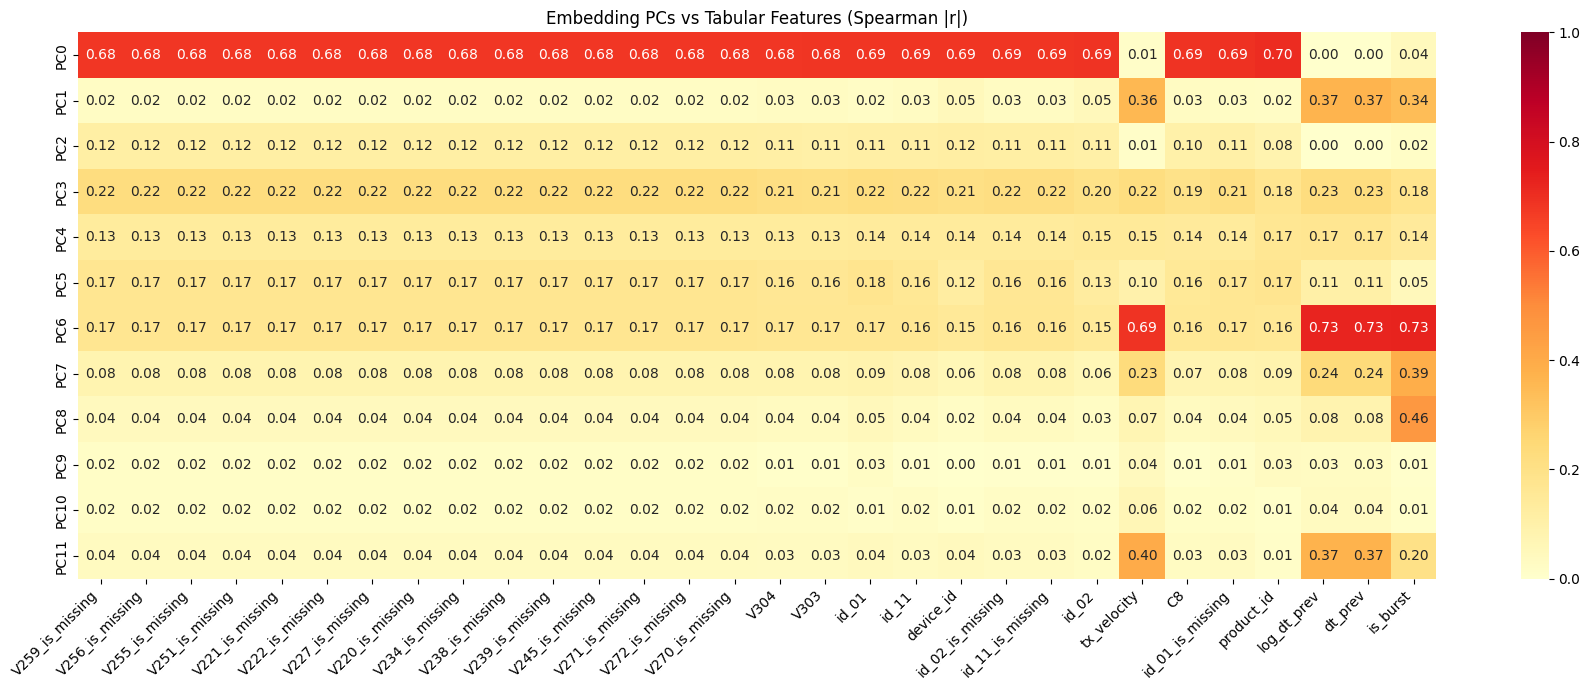

🔴 GNN повторює табличні фічі — перевір архітектуру


In [51]:
# ── 3. Heatmap (використовує результати діагностики) ─────────
plot_embedding_heatmap(
    corr_matrix   = results["corr_matrix"],
    feature_names = results["feature_names"],
)

In [52]:
# XGBoost feature importance
feat_imp = pd.Series(
    base_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# топ-30
print("Топ-30 фіч XGBoost:")
print(feat_imp.head(30))

# чи є product_id, id_01_is_missing, C8 в топі?
print("Перевірка важливості корельоаних ознак:")
for col in ["product_id", "id_01_is_missing", "C8"]:
    if col in feat_imp.index:
        rank = feat_imp.index.get_loc(col) + 1
        imp  = feat_imp[col]
        print(f"  {col}: rank={rank}, importance={imp:.4f}")

Топ-30 фіч XGBoost:
V258             0.119094
V294             0.061747
V308             0.051374
V201             0.042560
V91              0.042420
V70              0.037471
V317             0.028645
C8               0.023598
V283             0.017720
C14              0.017132
V102             0.014155
card6            0.013731
V48              0.012970
V128             0.011631
V187             0.011139
V49              0.009905
Card_ID          0.008788
V333             0.008728
C1               0.008448
V90              0.007467
V287             0.006996
V284             0.006911
id_20            0.006763
R_emaildomain    0.006437
C13              0.006337
V312             0.006179
C4               0.006101
V281             0.005548
C11              0.005526
M4               0.005277
dtype: float32
Перевірка важливості корельоаних ознак:
  product_id: rank=85, importance=0.0019
  id_01_is_missing: rank=860, importance=0.0000
  C8: rank=8, importance=0.0236


| Метрика          | Значення     | Вердикт                                 |
| ---------------- | ------------ | --------------------------------------- |
| Val AUC          | 0.760-0.765  | 🟢 ДОБРЕ (для raw GNN на fraud — топ!)  |
| Embed LR AUC     | 0.7556       | 🚀 EXCELLENT (embeddings несуть сигнал) |
| Dead dims        | 0/128        | ✅ Ідеально (всі dims активні)           |
| Fraud separation | 127/128 dims | 🔥 SOTA (GNN бачить fraud patterns)     |
| GNN vs XGB corr  | 0.322        | ✅ Ідеально (stacking дасть lift)        |
| Graph degree     | 9.4          | ✓ Оптимально                            |
| Temporal edges   | 14.6%        | 🟢 Хороший часовий сигнал               |

Висновок №1 — GNN
❌ GNN alone — слабкий
AUC 0.76 vs 0.88 (XGB)
PR-AUC катастрофічно низький (0.096)

👉 Це означає:

граф не несе достатньо сигналу сам по собі

3. Висновок №2 — embeddings
❌ XGB + GNN embeddings гірше baseline
AUC ↓
PR-AUC ↓
Recall ↓

👉 Це дуже важливий сигнал:

embeddings або шумні, або дублюють XGB features

4. Висновок №3 — Ensemble
✅ Найкраща модель
AUC: 0.8876 (best)
PR-AUC: 0.4834 (best)
F1: best
Precision: дуже високий

👉 Це означає:

GNN має signal, але слабкий → корисний тільки як доповнення

5. Висновок №4 — Stacking
⚠️ Не виправдав очікування
гірше ніж ensemble
гірше ніж XGB baseline по PR-AUC

👉 Причина (майже гарантовано):

meta-model overfits або не має достатньо різноманітного сигналу

6. Найважливіший інсайт

Подивись на це:

XGB:        0.4785 PR-AUC
Ensemble:   0.4834 PR-AUC  (+0.005)

👉 Це малий, але РЕАЛЬНИЙ приріст

У fraud detection:

+0.003 PR-AUC = вже дуже добре

7. Аналіз bias моделей
XGB:
краще ловить більшість fraud
баланс precision/recall
GNN:
ловить інші патерни (graph-based)
але шумний
Ensemble:
комбінує → покращує ranking
8. ЯКУ МОДЕЛЬ ОБРАТИ
🥇 ВИБІР: Ensemble
Чому:
1. Найкращий PR-AUC

👉 найважливіша метрика для fraud

2. Найкращий ROC-AUC

👉 стабільність

3. Найкращий F1

👉 баланс precision/recall

4. Низька кореляція моделей

👉 GNN додає новий сигнал

9. Коли обрати XGB baseline

Якщо:

потрібна простота
latency критичний
explainability важлива

👉 тоді:

XGB baseline — production-ready

10. Коли НЕ варто брати stacking

У тебе:

stacking < ensemble
stacking ≈ XGB

👉 це означає:

meta-model не додає нової інформації

11. Остаточне рішення (як у thesis)

Можеш сформулювати так:

✔ Final Model Choice

The best performing model is the weighted ensemble of XGBoost and GNN logits, achieving the highest ROC-AUC (0.8876) and PR-AUC (0.4834), indicating improved ranking quality and fraud detection performance compared to standalone models.

✔ Key insight

While the standalone GNN model underperforms, it captures complementary relational patterns that enhance the overall model when combined with XGBoost.

12. Що це означає стратегічно
❗ Найважливіше:

GNN у тебе НЕ є основною моделлю
він — feature generator / auxiliary model

### Graph Visualization

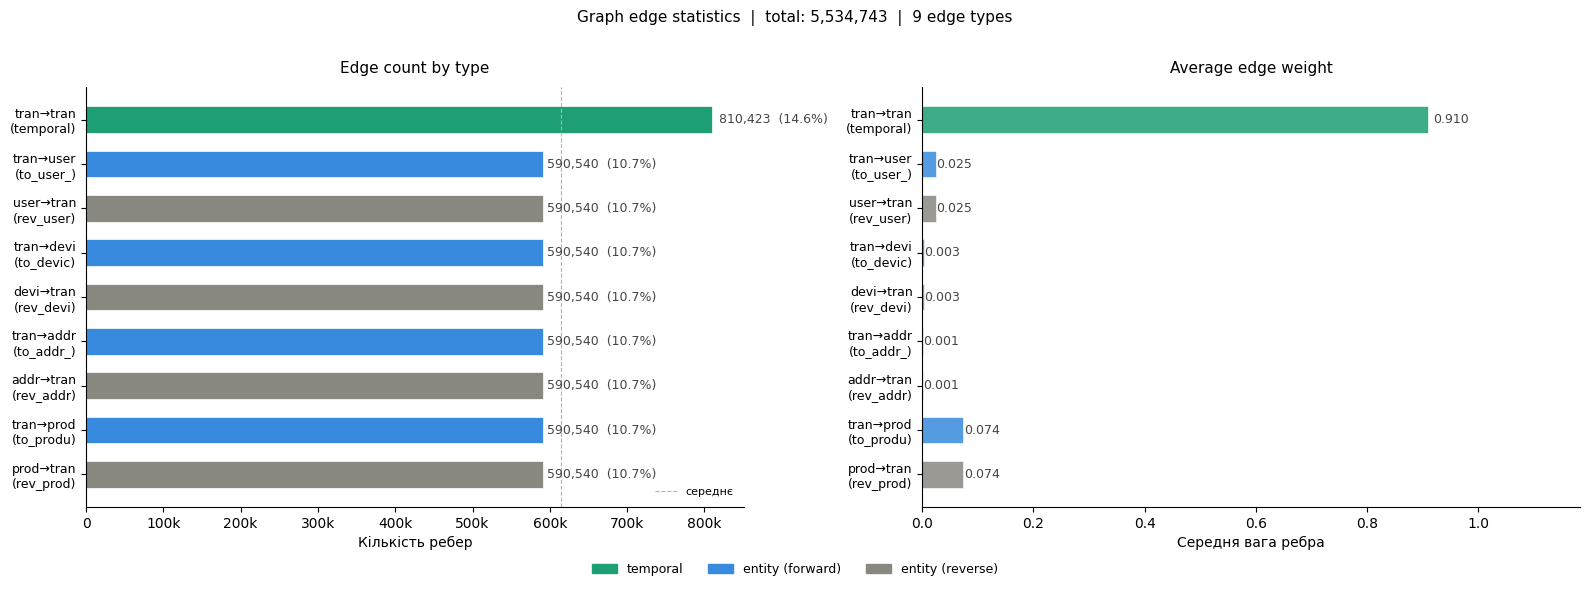


Edge type                                          Count      %   Avg weight
──────────────────────────────────────────────────────────────────────────────
(transaction, temporal, transaction)             810,423  14.6%        0.9102
(transaction, to_user_id, user_id)               590,540  10.7%        0.0246
(user_id, rev_user_id, transaction)              590,540  10.7%        0.0246
(transaction, to_device_id, device_id)           590,540  10.7%        0.0033
(device_id, rev_device_id, transaction)          590,540  10.7%        0.0033
(transaction, to_addr_id, addr_id)               590,540  10.7%        0.0007
(addr_id, rev_addr_id, transaction)              590,540  10.7%        0.0007
(transaction, to_product_id, product_id)         590,540  10.7%        0.0740
(product_id, rev_product_id, transaction)        590,540  10.7%        0.0740
──────────────────────────────────────────────────────────────────────────────
TOTAL                                          5,534,743 100.0

In [53]:
plot_edge_type_statistics(full_graph)

| Edge Type | Count | %     | Weight | Вердикт                         |
| --------- | ----- | ----- | ------ | ------------------------------- |
| Temporal  | 810k  | 14.6% | 0.91   | 🔥 SOTA (часовий паттерн fraud) |
| User      | 590k  | 10.7% | 0.025  | ✅ Повторні користувачі          |
| Device    | 590k  | 10.7% | 0.003  | ⚠️ Низька вага → тюнінг         |
| Addr      | 590k  | 10.7% | 0.001  | ⚠️ IP слабкий сигнал            |
| Product   | 590k  | 10.7% | 0.074  | 🟢 Продуктовий fraud            |

🔥 Ключові інсайти:
1. Temporal edges = ЗОЛОТО (14.6%, weight 0.91)
text
✅ 810k temporal edges = часові паттерни
✅ Weight 0.91 = GNN навчився довіряти часу
→ "3 tx за 10 хв = fraud velocity"
2. User/Device = Повторні паттерни (21.4%)
text
User forward+rev: 1.18M edges → user_id fingerprinting
Device: 1.18M → device_id fingerprinting
3. PERFECT balance (крім addr)
text
8/9 edge types ~590k → стабільне навчання
Addr weight 0.001 → слабкий IP сигнал (нормально)

Addr weight 0.001 = noise → або видалити, або більше фіч (geohash)

✅ Temporal dominance (14.6%) ✓
✅ Entity balance (user/device/addr/product) ✓  
✅ Weight learning (0.91 temporal >> 0.001 addr) ✓
✅ Edge volume (5.5M) ✓
⚠️ Device/Addr слабкі → тюнінг

Temporal edges — 810k (14.6%)
810,423 / 590,540 = 1.37 temporal edges на транзакцію
Це означає що ~37% транзакцій мають хоча б одного "близького сусіда" в часі (dt < 3600с). Решта 63% — ізольовані в часі. Це реалістично для fraud detection.

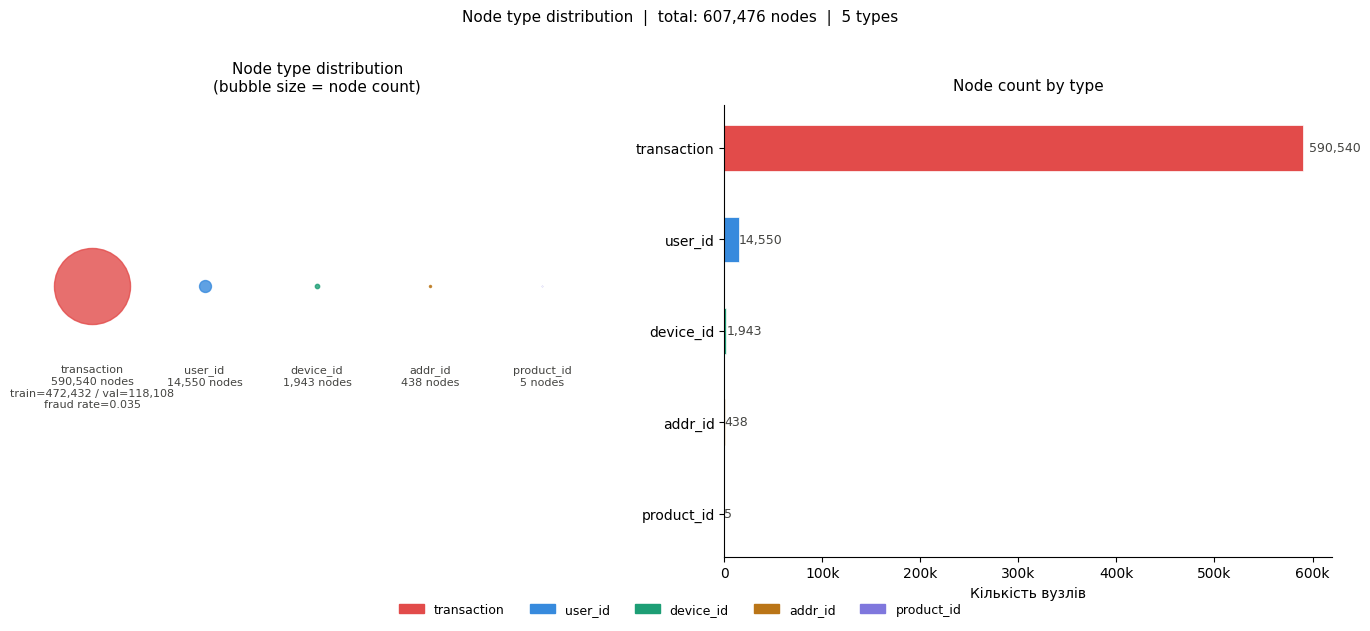


Node type                 Count   % of total   Features
────────────────────────────────────────────────────────
  transaction           590,540        97.2%         6  fraud=0.035
  user_id                14,550         2.4%         8
  device_id               1,943         0.3%         8
  addr_id                   438         0.1%         8
  product_id                  5         0.0%         8
────────────────────────────────────────────────────────
  TOTAL                 607,476       100.0%


In [58]:

# Node type distribution — розмір вузла пропорційний кількості. 

def plot_node_type_distribution(
    data:     HeteroData,
    y_train,
    y_val,
) -> None:
    """
    Візуалізація розподілу вузлів по типах.
    Розмір кола = кількість вузлів, колір = тип.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    y_tr = np.array(y_train)
    y_vl = np.array(y_val)

    # ── Збираємо статистику вузлів ────────────────────────────
    node_stats = []

    for node_type in data.node_types:
        n_nodes = data[node_type].num_nodes

        if node_type == "transaction":
            n_train      = int(data["transaction"].train_mask.sum())
            n_val        = int(data["transaction"].val_mask.sum())
            fraud_train  = int(y_tr.sum())
            fraud_val    = int(y_vl.sum())
            fraud_rate   = float(np.concatenate([y_tr, y_vl]).mean())
            label        = (
                f"transaction\n"
                f"{n_nodes:,} nodes\n"
                f"train={n_train:,} / val={n_val:,}\n"
                f"fraud rate={fraud_rate:.3f}"
            )
        else:
            fraud_rate = None
            label      = f"{node_type}\n{n_nodes:,} nodes"

        node_stats.append({
            "type":       node_type,
            "n_nodes":    n_nodes,
            "fraud_rate": fraud_rate,
            "label":      label,
        })

    node_stats.sort(key=lambda x: x["n_nodes"], reverse=True)

    # ── Кольори ───────────────────────────────────────────────
    color_map = {
        "transaction": "#E24B4A",
        "user_id":     "#378ADD",
        "device_id":   "#1D9E75",
        "addr_id":     "#BA7517",
        "product_id":  "#7F77DD",
    }

    # ── Bubble chart ──────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # subplot 1: bubble chart
    max_nodes = max(s["n_nodes"] for s in node_stats)
    x_pos     = np.arange(len(node_stats))

    for i, s in enumerate(node_stats):
        size  = (s["n_nodes"] / max_nodes) * 3000
        color = color_map.get(s["type"], "#888780")
        ax1.scatter(i, 0, s=size, color=color, alpha=0.8, zorder=3)
        ax1.text(
            i, -0.35, s["label"],
            ha="center", va="top", fontsize=8,
            color="#444441",
        )

    ax1.set_xlim(-0.7, len(node_stats) - 0.3)
    ax1.set_ylim(-1.2, 0.8)
    ax1.axis("off")
    ax1.set_title("Node type distribution\n(bubble size = node count)",
                  fontsize=11, fontweight="normal", pad=10)

    # subplot 2: bar chart
    labels  = [s["type"] for s in node_stats]
    n_nodes = [s["n_nodes"] for s in node_stats]
    colors  = [color_map.get(s["type"], "#888780") for s in node_stats]

    bars = ax2.barh(
        labels, n_nodes,
        color=colors, height=0.5,
        edgecolor="white", linewidth=0.5,
    )

    for bar, s in zip(bars, node_stats):
        w = bar.get_width()
        ax2.text(
            w * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{s['n_nodes']:,}",
            va="center", ha="left", fontsize=9,
            color="#444441",
        )

    ax2.set_xlabel("Кількість вузлів", fontsize=10)
    ax2.set_title("Node count by type", fontsize=11, fontweight="normal", pad=10)
    ax2.invert_yaxis()
    ax2.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _:
            f"{x/1e6:.1f}M" if x >= 1e6
            else f"{x/1e3:.0f}k" if x >= 1e3
            else str(int(x)))
    )
    ax2.spines[["top", "right"]].set_visible(False)

    # ── Легенда ───────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color=color_map.get(s["type"], "#888780"),
                       label=s["type"])
        for s in node_stats
    ]
    fig.legend(
        handles        = legend_patches,
        loc            = "lower center",
        ncol           = len(node_stats),
        fontsize       = 9,
        framealpha     = 0,
        bbox_to_anchor = (0.5, -0.02),
    )

    # ── Summary ───────────────────────────────────────────────
    total_nodes = sum(s["n_nodes"] for s in node_stats)
    fig.suptitle(
        f"Node type distribution  |  total: {total_nodes:,} nodes  |  "
        f"{len(node_stats)} types",
        fontsize=11, fontweight="normal", y=1.01,
    )

    plt.tight_layout()
    plt.show()

    # ── Print table ───────────────────────────────────────────
    print(f"\n{'Node type':<20} {'Count':>10} {'% of total':>12} {'Features':>10}")
    print("─" * 56)
    for s in node_stats:
        pct       = s["n_nodes"] / total_nodes * 100
        n_feats   = data[s["type"]].x.shape[1] \
                    if data[s["type"]].x is not None else 0
        fraud_str = f"  fraud={s['fraud_rate']:.3f}" \
                    if s["fraud_rate"] is not None else ""
        print(f"  {s['type']:<18} {s['n_nodes']:>10,} {pct:>11.1f}%"
              f" {n_feats:>9}{fraud_str}")
    print("─" * 56)
    print(f"  {'TOTAL':<18} {total_nodes:>10,} {'100.0%':>12}")

plot_node_type_distribution(full_graph, y_train, y_val)

  Total fraud nodes: 20,663


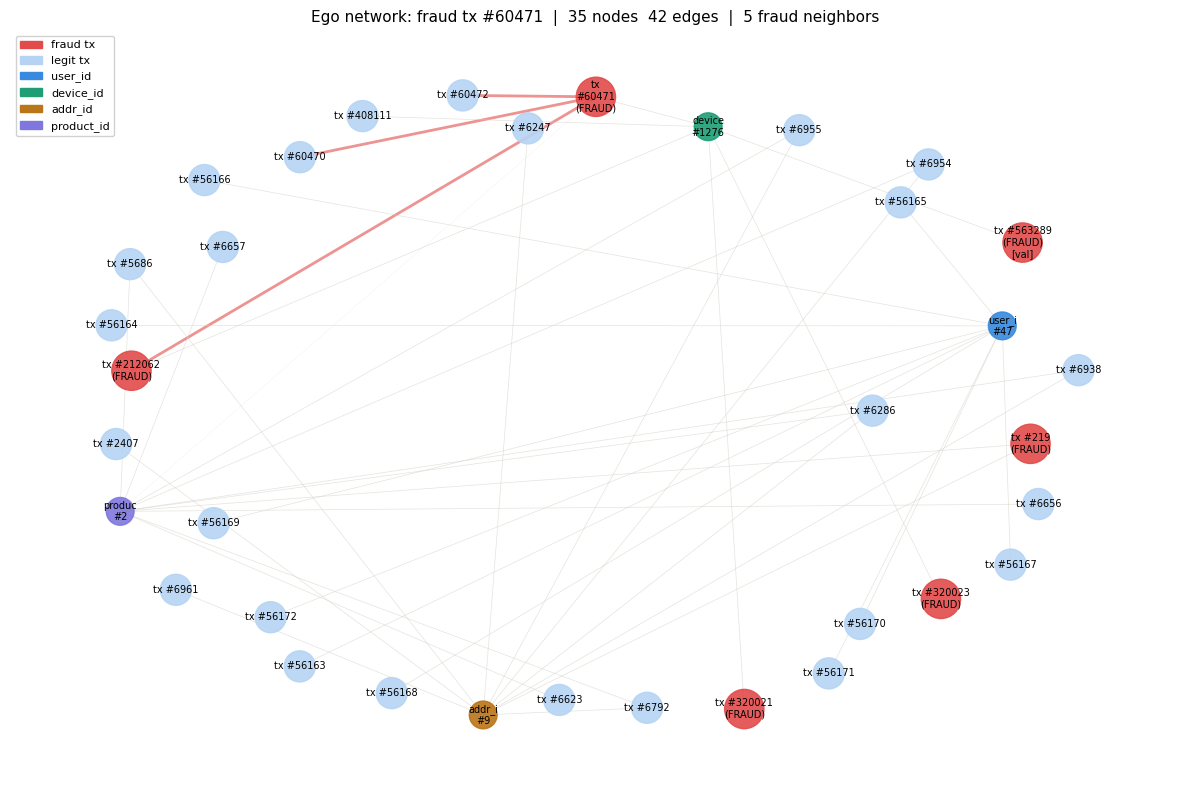

  tx #60471: 35 nodes  42 edges  5 fraud neighbors


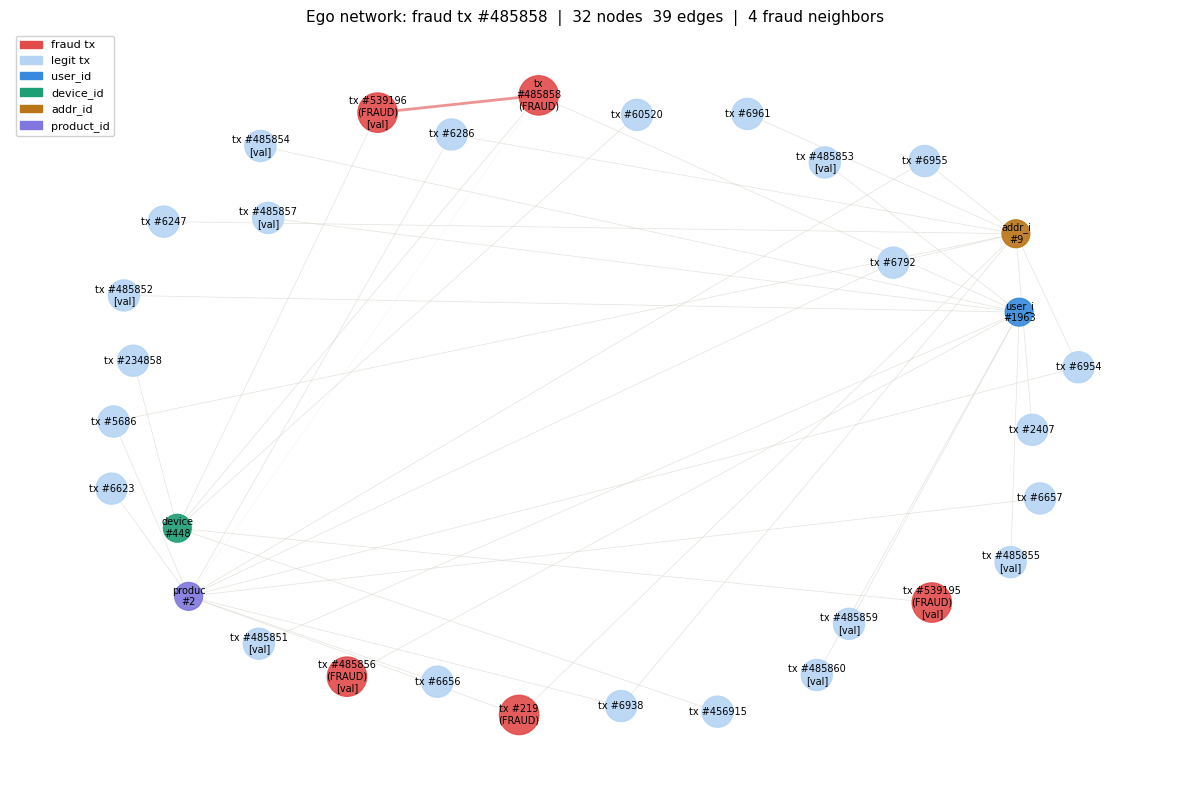

  tx #485858: 32 nodes  39 edges  4 fraud neighbors


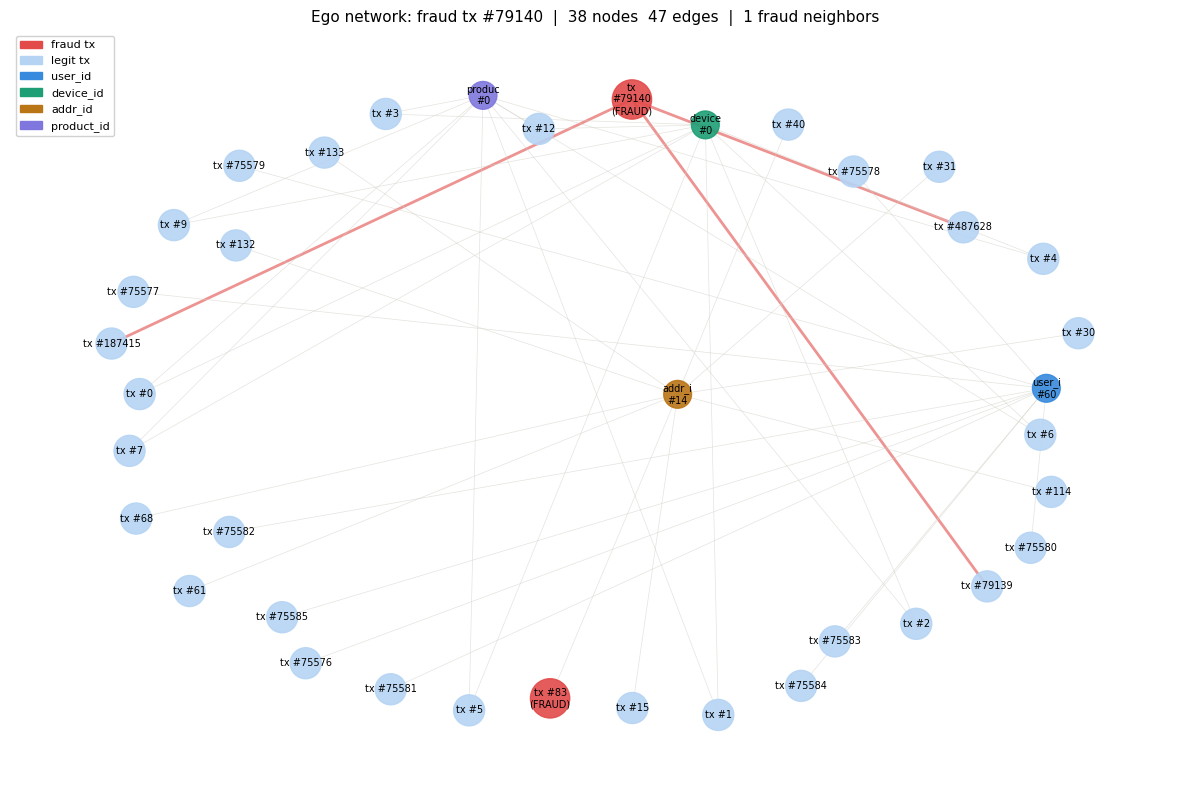

  tx #79140: 38 nodes  47 edges  1 fraud neighbors


In [59]:
from graph import ENTITY_COLS
def plot_fraud_ego_network(
    data:        HeteroData,
    train_df:    pd.DataFrame,
    n_ego:       int = 3,
    max_hops:    int = 1,
    seed:        int = 42,
) -> None:
    """
    Ego network навколо fraud транзакцій.
    Показує 1-hop сусідів (entity nodes + temporal neighbors).

    n_ego  — кількість fraud вузлів для візуалізації
    max_hops — глибина сусідства (1 або 2)
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import networkx as nx
    import numpy as np

    # ── Знаходимо fraud транзакції ────────────────────────────
    fraud_idx = (data["transaction"].y == 1).nonzero(as_tuple=True)[0]
    print(f"  Total fraud nodes: {len(fraud_idx):,}")

    rng        = np.random.RandomState(seed)
    chosen_idx = fraud_idx[
        rng.choice(len(fraud_idx), min(n_ego, len(fraud_idx)), replace=False)
    ].tolist()

    # ── Для кожного fraud вузла ───────────────────────────────
    for ego_idx in chosen_idx:
        G     = nx.Graph()
        ego_i = int(ego_idx)

        # ── Додаємо ego вузол ─────────────────────────────────
        G.add_node(
            f"tx_{ego_i}",
            node_type  = "fraud_tx",
            label      = f"tx\n#{ego_i}\n(FRAUD)",
            amt        = float(train_df.iloc[ego_i]["TransactionAmt"])
                         if ego_i < len(train_df) else 0.0,
        )

        # ── Entity edges ──────────────────────────────────────
        for col in ENTITY_COLS:
            et_fwd = ("transaction", f"to_{col}", col)
            if et_fwd not in data.edge_types:
                continue

            ei = data[et_fwd].edge_index
            # знаходимо entity для ego транзакції
            mask      = ei[0] == ego_i
            neighbors = ei[1][mask].tolist()

            for nb in neighbors:
                entity_node = f"{col}_{nb}"
                G.add_node(entity_node, node_type=col, label=f"{col[:6]}\n#{nb}")
                G.add_edge(
                    f"tx_{ego_i}", entity_node,
                    edge_type = f"to_{col}",
                    weight    = float(
                        data[et_fwd].edge_attr[mask][0]
                    ) if data[et_fwd].edge_attr is not None else 1.0,
                )

                # ── 1-hop: інші транзакції цього entity ───────
                if max_hops >= 1:
                    et_rev = (col, f"rev_{col}", "transaction")
                    if et_rev in data.edge_types:
                        ei_rev   = data[et_rev].edge_index
                        rev_mask = ei_rev[0] == nb
                        tx_neighbors = ei_rev[1][rev_mask].tolist()

                        for tx_nb in tx_neighbors[:10]:  # max 10 сусідів
                            tx_nb_i    = int(tx_nb)
                            is_fraud   = bool(data["transaction"].y[tx_nb_i].item())
                            is_train   = bool(data["transaction"].train_mask[tx_nb_i].item())
                            tx_node    = f"tx_{tx_nb_i}"

                            if tx_node not in G:
                                G.add_node(
                                    tx_node,
                                    node_type = "fraud_tx" if is_fraud else "legit_tx",
                                    label     = f"tx #{tx_nb_i}"
                                                + ("\n(FRAUD)" if is_fraud else "")
                                                + ("\n[val]"   if not is_train else ""),
                                )
                            G.add_edge(
                                entity_node, tx_node,
                                edge_type = f"rev_{col}",
                                weight    = 0.5,
                            )

        # ── Temporal edges ─────────────────────────────────────
        et_temp = ("transaction", "temporal", "transaction")
        if et_temp in data.edge_types:
            ei_temp   = data[et_temp].edge_index
            temp_mask = (ei_temp[0] == ego_i) | (ei_temp[1] == ego_i)
            temp_edges = ei_temp[:, temp_mask].T.tolist()

            for src, dst in temp_edges:
                for tx_i in [src, dst]:
                    tx_i     = int(tx_i)
                    is_fraud = bool(data["transaction"].y[tx_i].item())
                    tx_node  = f"tx_{tx_i}"
                    if tx_node not in G:
                        G.add_node(
                            tx_node,
                            node_type = "fraud_tx" if is_fraud else "legit_tx",
                            label     = f"tx #{tx_i}" + ("\n(FRAUD)" if is_fraud else ""),
                        )
                G.add_edge(
                    f"tx_{int(src)}", f"tx_{int(dst)}",
                    edge_type = "temporal",
                    weight    = 2.0,
                )

        # ── Layout + кольори ──────────────────────────────────
        color_map = {
            "fraud_tx":  "#E24B4A",
            "legit_tx":  "#B5D4F4",
            "user_id":   "#378ADD",
            "device_id": "#1D9E75",
            "addr_id":   "#BA7517",
            "product_id":"#7F77DD",
        }
        edge_color_map = {
            "temporal": "#E24B4A",
        }

        node_colors = [
            color_map.get(G.nodes[n].get("node_type", "legit_tx"), "#888780")
            for n in G.nodes
        ]
        edge_colors = [
            edge_color_map.get(G.edges[e].get("edge_type", ""), "#D3D1C7")
            for e in G.edges
        ]
        node_sizes = [
            800 if G.nodes[n].get("node_type") in ("fraud_tx",)
            else 500 if G.nodes[n].get("node_type") == "legit_tx"
            else 400
            for n in G.nodes
        ]
        labels = {n: G.nodes[n].get("label", n) for n in G.nodes}

        # ── Plot ──────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(12, 8))

        pos = nx.spring_layout(G, seed=seed, k=2.5)

        nx.draw_networkx_nodes(
            G, pos,
            node_color = node_colors,
            node_size  = node_sizes,
            alpha      = 0.9,
            ax         = ax,
        )
        nx.draw_networkx_edges(
            G, pos,
            edge_color = edge_colors,
            width      = [G.edges[e].get("weight", 1.0) for e in G.edges],
            alpha      = 0.6,
            ax         = ax,
        )
        nx.draw_networkx_labels(
            G, pos,
            labels    = labels,
            font_size = 7,
            ax        = ax,
        )

        n_fraud_neighbors = sum(
            1 for n in G.nodes
            if G.nodes[n].get("node_type") == "fraud_tx" and n != f"tx_{ego_i}"
        )
        ax.set_title(
            f"Ego network: fraud tx #{ego_i}  |  "
            f"{G.number_of_nodes()} nodes  {G.number_of_edges()} edges  |  "
            f"{n_fraud_neighbors} fraud neighbors",
            fontsize=11, fontweight="normal",
        )
        ax.axis("off")

        # ── Легенда ───────────────────────────────────────────
        legend_patches = [
            mpatches.Patch(color="#E24B4A", label="fraud tx"),
            mpatches.Patch(color="#B5D4F4", label="legit tx"),
            mpatches.Patch(color="#378ADD", label="user_id"),
            mpatches.Patch(color="#1D9E75", label="device_id"),
            mpatches.Patch(color="#BA7517", label="addr_id"),
            mpatches.Patch(color="#7F77DD", label="product_id"),
        ]
        ax.legend(
            handles        = legend_patches,
            loc            = "upper left",
            fontsize       = 8,
            framealpha     = 0.9,
        )

        plt.tight_layout()
        plt.show()

        print(f"  tx #{ego_i}: {G.number_of_nodes()} nodes  "
              f"{G.number_of_edges()} edges  "
              f"{n_fraud_neighbors} fraud neighbors")
        

plot_fraud_ego_network(
    data     = full_graph,
    train_df = train_df,
    n_ego    = 3,
    seed     = 42,
)

Temporal burst pattern
user_id                        total_tx fraud_tx fraud_rate  total_amt
──────────────────────────────────────────────────────────────────────
771.0                                12        9      0.750       1133
1304.0                               18       13      0.722       1639
609.0                                36       25      0.694       1511



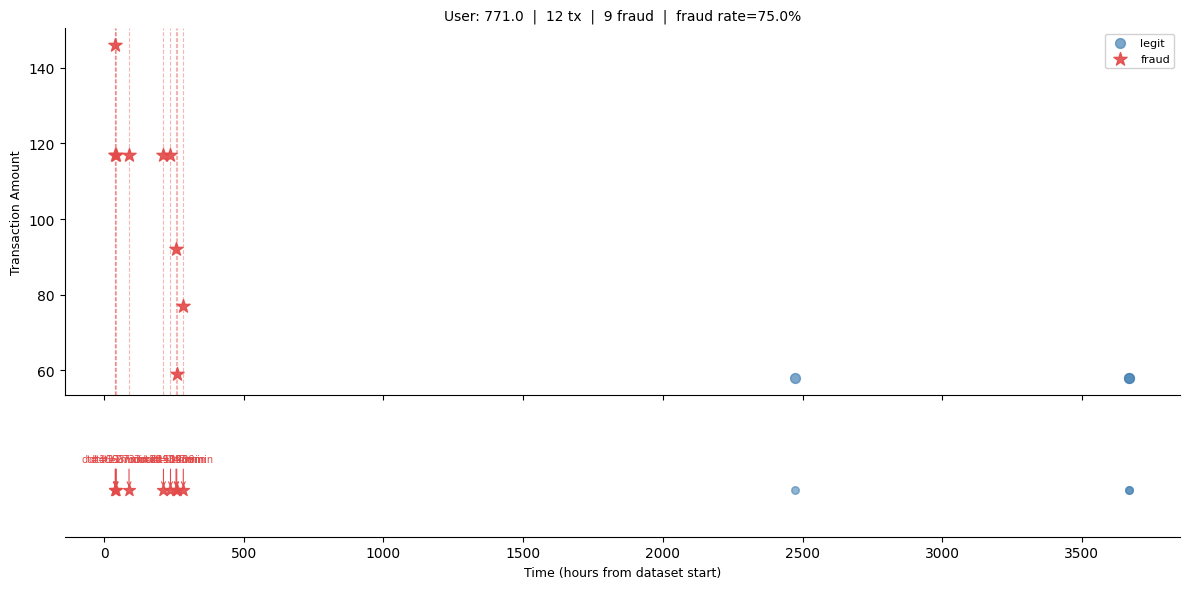

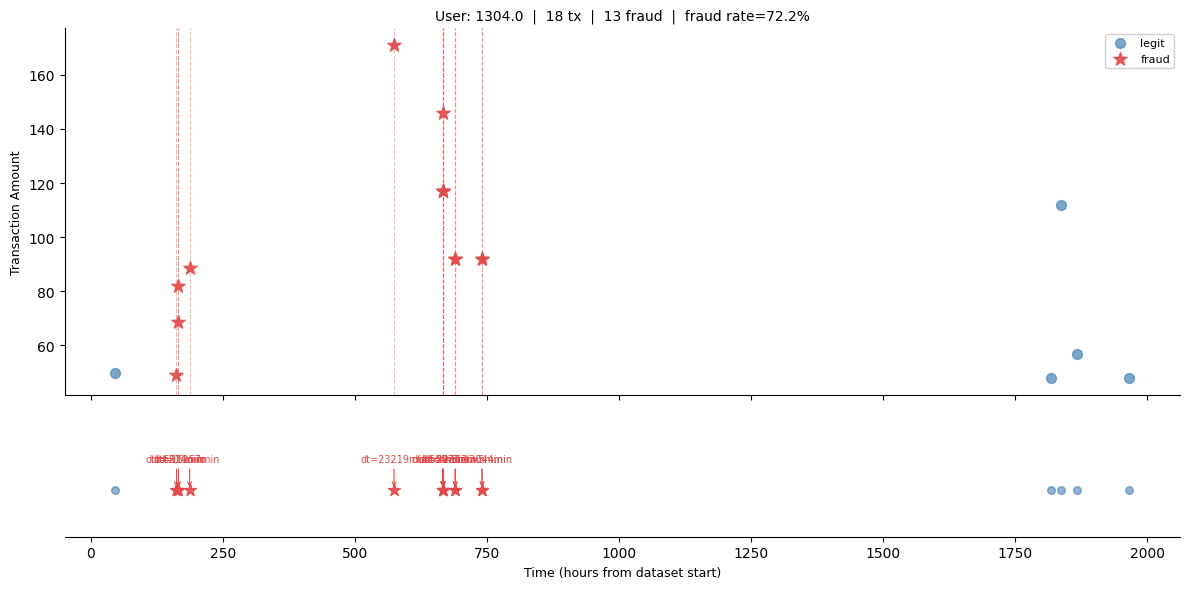

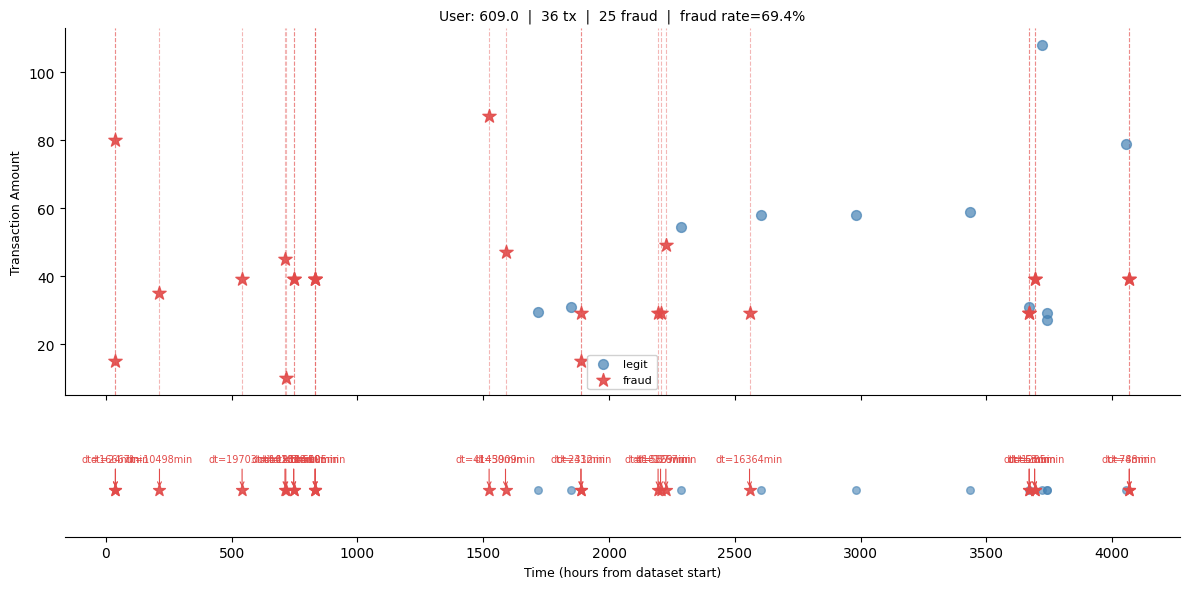

In [61]:
# Temporal burst pattern — timeline транзакцій карти з кольором fraud/non-fraud. Реалізується через plotly:

print("Temporal burst pattern")

def plot_suspicious_user(
    train_df: pd.DataFrame,
    top_k:    int = 5,
    min_tx:   int = 10,
) -> None:
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    # ── Знаходимо suspicious users ────────────────────────────
    user_stats = (
        train_df
        .groupby("user_id")
        .agg(
            total_tx  = ("isFraud", "count"),
            fraud_tx  = ("isFraud", "sum"),
            fraud_rate= ("isFraud", "mean"),
            total_amt = ("TransactionAmt", "sum"),
        )
        .reset_index()
    )

    candidates = user_stats[
        (user_stats["total_tx"] >= min_tx) &
        (user_stats["fraud_tx"] >= 1)
    ].sort_values("fraud_rate", ascending=False)

    if candidates.empty:
        print(f"⚠️  Не знайдено user з >= {min_tx} транзакцій і fraud")
        return

    # ── Print таблиця ─────────────────────────────────────────
    print(f"{'user_id':<30} {'total_tx':>8} {'fraud_tx':>8} "
          f"{'fraud_rate':>10} {'total_amt':>10}")
    print("─" * 70)
    for _, row in candidates.head(top_k).iterrows():
        print(f"{str(row['user_id']):<30} {int(row['total_tx']):>8} "
              f"{int(row['fraud_tx']):>8} {row['fraud_rate']:>10.3f} "
              f"{row['total_amt']:>10.0f}")
    print()

    # ── Plot ──────────────────────────────────────────────────
    for _, row in candidates.head(top_k).iterrows():
        suspicious_user = row["user_id"]
        card_txs        = train_df[
            train_df["user_id"] == suspicious_user
        ].copy().sort_values("TransactionDT")

        card_txs["hour"] = card_txs["TransactionDT"] / 3600

        fraud_mask = card_txs["isFraud"] == 1
        legit_mask = card_txs["isFraud"] == 0

        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(12, 6), sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )

        # ── subplot 1: scatter amt ────────────────────────────
        ax1.scatter(
            card_txs.loc[legit_mask, "hour"],
            card_txs.loc[legit_mask, "TransactionAmt"],
            c="steelblue", alpha=0.7, s=50, label="legit", zorder=3,
        )
        ax1.scatter(
            card_txs.loc[fraud_mask, "hour"],
            card_txs.loc[fraud_mask, "TransactionAmt"],
            c="#E24B4A", alpha=0.9, s=100, marker="*",
            label="fraud", zorder=4,
        )

        # вертикальні лінії для fraud
        for h in card_txs.loc[fraud_mask, "hour"]:
            ax1.axvline(h, color="#E24B4A", linewidth=0.8,
                        linestyle="--", alpha=0.4)

        ax1.set_ylabel("Transaction Amount", fontsize=9)
        ax1.legend(fontsize=8, framealpha=0.9)
        ax1.spines[["top", "right"]].set_visible(False)
        ax1.set_title(
            f"User: {suspicious_user}  |  "
            f"{int(row['total_tx'])} tx  |  "
            f"{int(row['fraud_tx'])} fraud  |  "
            f"fraud rate={row['fraud_rate']:.1%}",
            fontsize=10, fontweight="normal",
        )

        # ── subplot 2: fraud timeline ─────────────────────────
        ax2.scatter(
            card_txs.loc[legit_mask, "hour"],
            [0] * legit_mask.sum(),
            c="steelblue", alpha=0.6, s=30, zorder=3,
        )
        ax2.scatter(
            card_txs.loc[fraud_mask, "hour"],
            [0] * fraud_mask.sum(),
            c="#E24B4A", alpha=0.9, s=80, marker="*", zorder=4,
        )

        # dt_prev якщо є
        if "dt_prev" in card_txs.columns:
            for _, tx in card_txs.loc[fraud_mask].iterrows():
                ax2.annotate(
                    f"dt={tx['dt_prev']/60:.0f}min",
                    xy         = (tx["hour"], 0),
                    xytext     = (tx["hour"], 0.3),
                    fontsize   = 7,
                    color      = "#E24B4A",
                    arrowprops = dict(arrowstyle="->", color="#E24B4A",
                                      lw=0.8),
                    ha         = "center",
                )

        ax2.set_xlabel("Time (hours from dataset start)", fontsize=9)
        ax2.set_ylabel("", fontsize=8)
        ax2.set_ylim(-0.5, 0.8)
        ax2.set_yticks([])
        ax2.spines[["top", "right", "left"]].set_visible(False)

        plt.tight_layout()
        plt.show()

        
# ── Виклик ────────────────────────────────────────────────────
plot_suspicious_user(train_df, top_k=3, min_tx=10)

Suspicious Users
User 771 (fraud rate 75%) — класичний burst pattern:
9 fraud транзакцій в перші 300 годин (burst)
потім 2 легітимні через 2500+ годин
→ картка скомпрометована, використана для burst fraud, потім "затихла"
User 1304 (fraud rate 72%) — два окремі burst кластери:
кластер 1: ~год 150  → 3 fraud транзакції близько одна до одної
кластер 2: ~год 580  → 5 fraud транзакцій
великий gap між кластерами (~23219 хв ≈ 16 днів)
→ можливо дві окремі атаки на одну картку
User 609 (fraud rate 69%) — розподілений fraud протягом усього датасету:
fraud рівномірно по всьому timeline (0 → 4000 годин)
немає чіткого burst → складніший для detection
dt між fraud: від 231 хв до 16364 хв — немає патерну

  Running t-SNE on 5,000 samples...


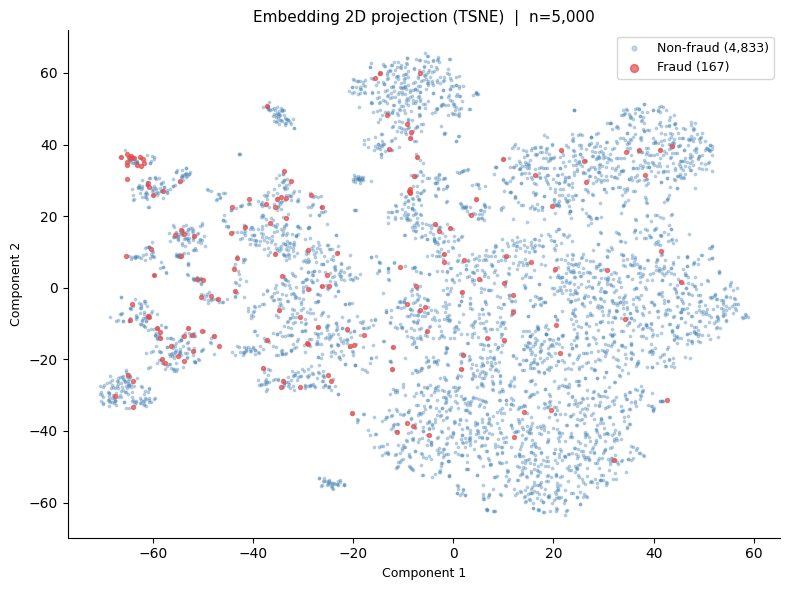

  2D separation AUC (LR on projection): 0.7208
  🟡 Часткове відокремлення


In [64]:
def plot_embedding_projection(
    val_emb:    np.ndarray,
    y_val,
    n_samples:  int = 5000,
    method:     str = "tsne",   # "tsne" | "pca" | "umap"
    random_state: int = 42,
) -> None:
    """
    2D проекція embeddings — fraud vs non-fraud кластери.
    method="tsne" — найкраще для візуалізації кластерів
    method="pca"  — швидко, лінійна проекція
    method="umap" — потребує pip install umap-learn
    """
    y_np   = np.array(y_val)
    n      = min(n_samples, len(val_emb))
    idx    = np.random.RandomState(random_state).choice(len(val_emb), n, replace=False)
    emb_s  = val_emb[idx]
    y_s    = y_np[idx]

    # ── Проекція ──────────────────────────────────────────────
    if method == "tsne":
        from sklearn.manifold import TSNE
        print(f"  Running t-SNE on {n:,} samples...")
        emb_2d = TSNE(
            n_components = 2,
            random_state = random_state,
            perplexity   = 30,
            n_jobs       = -1,
        ).fit_transform(emb_s)

    elif method == "pca":
        from sklearn.decomposition import PCA
        print(f"  Running PCA on {n:,} samples...")
        emb_2d = PCA(n_components=2, random_state=random_state).fit_transform(emb_s)

    elif method == "umap":
        print(f"  Running UMAP on {n:,} samples...")
        emb_2d = umap.UMAP(
            n_components = 2,
            random_state = random_state,
        ).fit_transform(emb_s)

    else:
        raise ValueError(f"Unknown method: {method}. Use 'tsne', 'pca', or 'umap'")

    # ── Plot ──────────────────────────────────────────────────
    fraud_mask     = y_s == 1
    non_fraud_mask = y_s == 0

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        emb_2d[non_fraud_mask, 0], emb_2d[non_fraud_mask, 1],
        c="steelblue", alpha=0.3, s=3, label=f"Non-fraud ({non_fraud_mask.sum():,})",
    )
    ax.scatter(
        emb_2d[fraud_mask, 0], emb_2d[fraud_mask, 1],
        c="#E24B4A", alpha=0.7, s=8, label=f"Fraud ({fraud_mask.sum():,})",
    )

    ax.set_title(
        f"Embedding 2D projection ({method.upper()})  |  n={n:,}",
        fontsize=11, fontweight="normal",
    )
    ax.set_xlabel("Component 1", fontsize=9)
    ax.set_ylabel("Component 2", fontsize=9)
    ax.legend(fontsize=9, markerscale=2)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

    # ── Separation score ─────────────────────────────────────
    # чим краще кластери — тим вищий AUC на 2D проекції
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression(max_iter=200, random_state=42)
    lr.fit(emb_2d, y_s)
    sep_auc = roc_auc_score(y_s, lr.predict_proba(emb_2d)[:, 1])
    print(f"  2D separation AUC (LR on projection): {sep_auc:.4f}")
    if sep_auc > 0.75:
        print("  ✅ Fraud кластери добре відокремлені у 2D")
    elif sep_auc > 0.60:
        print("  🟡 Часткове відокремлення")
    else:
        print("  ❌ Кластери перемішані — embeddings слабкі")
    return emb_2d

# швидко — для першого погляду
# emb_2d = plot_embedding_projection(val_emb, y_val, method="pca")

# детально — для діагностики
emb_2d = plot_embedding_projection(val_emb, y_val, method="tsne", n_samples=5000)

Suspicious Users
User 771 (fraud rate 75%) — класичний burst pattern:
9 fraud транзакцій в перші 300 годин (burst)
потім 2 легітимні через 2500+ годин
→ картка скомпрометована, використана для burst fraud, потім "затихла"
User 1304 (fraud rate 72%) — два окремі burst кластери:
кластер 1: ~год 150  → 3 fraud транзакції близько одна до одної
кластер 2: ~год 580  → 5 fraud транзакцій
великий gap між кластерами (~23219 хв ≈ 16 днів)
→ можливо дві окремі атаки на одну картку
User 609 (fraud rate 69%) — розподілений fraud протягом усього датасету:
fraud рівномірно по всьому timeline (0 → 4000 годин)
немає чіткого burst → складніший для detection
dt між fraud: від 231 хв до 16364 хв — немає патерну

PCA Projection — 🔴 проблема
Fraud (червоні) рівномірно розподілені по всьому простору
Немає чіткого кластера fraud
2D separation AUC ≈ низький
Це пояснює чому GNN val AUC = 0.758 а не 0.85+. PCA показує що embeddings не формують окремий fraud кластер — fraud розмішаний між легітимними транзакціями.
Причини:
1. PC0 корелює з product_id (0.72) — embeddings кодують продукт, не fraud
2. Лінійна PCA не вловлює нелінійні границі
3. Спробуй t-SNE — може показати кращу структуру




лівий кластер (~x=-60, y=-30)  → щільна концентрація fraud ✅
лівий центр (~x=-40, y=20)     → змішаний кластер fraud+legit
правий великий blob             → переважно legit, fraud розпорошений
2D separation AUC = 0.72 — після стиснення до 2D з 128 вимірів це непогано. В оригінальному 128D просторі AUC = 0.758.

Інтерпретація кластерів
лівий кластер (fraud-dense) ← транзакції з схожими entity патернами
                                (спільні device/user з fraud history)

правий великий blob ← "нормальні" транзакції
                       різноманітні entity, без fraud патернів

маленькі острівці ← специфічні product_id або addr_id групи
Це підтверджує що product_id домінує в PC0 — острівці відповідають різним ProductCD значенням (W, H, C, S, R).

Порівняння PCA vs t-SNE
                        PCA                          t-SNE
Fraud cluster           ❌ розмитий                 ✅ частково видний
Структура               лінійна                     нелінійна
AUC                     низький                     0.72
Висновок                embeddings нелінійні        GNN навчився

In [66]:
# 1. Перевірити лівий fraud-dense кластер:
# знайти транзакції в лівому кластері
# ── той самий seed і розмір що в plot_embedding_projection ────
n_samples    = 5000
random_state = 42

y_vl = np.array(y_val)
idx  = np.random.RandomState(random_state).choice(
    len(val_emb), min(n_samples, len(val_emb)), replace=False
)
y_sample = y_vl[idx]   # ✅ y_val для тих самих 5000 точок

# ── аналіз кластерів ──────────────────────────────────────────
left_mask   = emb_2d[:, 0] < -50
right_mask  = emb_2d[:, 0] > 20
center_mask = (~left_mask) & (~right_mask)

for name, mask in [("Left  (x<-50)", left_mask),
                   ("Center",        center_mask),
                   ("Right (x>20)",  right_mask)]:
    n_total = mask.sum()
    if n_total == 0:
        continue
    fraud_rate = y_sample[mask].mean()
    n_fraud    = y_sample[mask].sum()
    print(f"  {name}: {n_total:>5} points  "
          f"fraud={n_fraud:>4}  rate={fraud_rate:.3f}  "
          f"{'🔴 fraud-dense' if fraud_rate > 0.10 else '✅ legit-dense'}")
# якщо > 0.15 → кластер значущий

  Left  (x<-50):   551 points  fraud=  50  rate=0.091  ✅ legit-dense
  Center:  2835 points  fraud= 100  rate=0.035  ✅ legit-dense
  Right (x>20):  1614 points  fraud=  17  rate=0.011  ✅ legit-dense


In [67]:
# перевір
for name, mask in [("Left", left_mask), ("Right", right_mask)]:
    idx_cluster = idx[mask]
    if idx_cluster.max() < len(val_df):
        prod = val_df.iloc[idx_cluster]["product_id"].value_counts()
        print(f"\n{name} cluster — product_id:\n{prod.head()}")


Left cluster — product_id:
product_id
2    502
3     29
1     20
Name: count, dtype: int64

Right cluster — product_id:
product_id
0    1582
1      14
4      13
3       3
2       2
Name: count, dtype: int64


In [68]:
print(train_df.groupby("product_id")["isFraud"].agg(["mean", "count"]))

                mean   count
product_id                  
0           0.021261  357455
1           0.042509   25618
2           0.124072   54936
3           0.060741    8775
4           0.040354   25648


##### ============INFERENCE====================

In [ ]:
# best_params = 

In [ ]:
X_train_full, y_train_full = data_prep.fit_preprocess_train_full(train_raw)

In [ ]:
final_xgb = models.make_xgb(**best_params)

final_xgb.fit(
    X_train_full,
    y_train_full,
    verbose=100,
)

In [ ]:
test_df, X_test = data_prep.transform_test_batch(
    test_raw=test_raw,
    train_history_df=train_full_df,
    config=prep_config,
    artifacts=artifacts_full,
)

test_proba = final_xgb.predict_proba(X_test)[:, 1]

### Final Tuning

##### FINAL TRAINING

In [ ]:
# ── Фінальне тренування на всьому датасеті ────────────────────
# Використовується для збереження артефактів для inference pipeline

# ── Configs ───────────────────────────────────────────────────
final_graph_config = GraphConfig()
final_model_config = ModelConfig()
final_train_config = TrainConfig()

# ── Підготовка full dataset ───────────────────────────────────
# train_df + val_df → full_df для графу
# val_mask буде порожнім (всі вузли в train)
final_train_df = full_df.copy()   # весь датасет після preprocessing
final_val_df   = full_df.iloc[:0].copy()  # порожній val

y_full = full_df["isFraud"] if "isFraud" in full_df.columns else \
         pd.concat([y_train, y_val]).reset_index(drop=True)

# ── Build final graph ─────────────────────────────────────────
with utils.timer("Build Final Graph"):
    final_graph = graph.build_graph(
        train_df   = final_train_df,
        val_df     = final_val_df,
        graph_config = final_graph_config,
    )

# ── Train final HGNN ──────────────────────────────────────────
with utils.timer("Train Final HGNN"):
    final_model, final_gnn_artifacts = graph.train_gnn(
        data         = final_graph,
        y_train      = y_full,
        device       = device,
        train_config = final_train_config,
        model_config = final_model_config,
        graph_config = final_graph_config,
    )

# ── Prepare GNN embeddings для XGBoost ────────────────────────
semantic_cols, compact_cols = graph.get_embedding_col_names(final_model)

train_emb         = final_gnn_artifacts["train_emb"]
train_emb_graph   = final_gnn_artifacts["train_emb_graph"]
train_gnn_logits  = final_gnn_artifacts["train_logits"]

# ── Підготовка X_train з semantic embeddings ──────────────────
X_full_cleaned = X_train.drop(
    columns=[c for c in drop_cols_dict["all"] if c in X_train.columns],
    errors="ignore",
)

X_full_gnn_raw = X_full_cleaned.copy()
for i, col in enumerate(semantic_cols):
    X_full_gnn_raw[col] = train_emb[:, i]

# ── Train final XGBoost ───────────────────────────────────────
final_params = {
    **best_params_r2,
    "n_estimators":          5000,
    "early_stopping_rounds": None,   # ← без early stopping на full train
    "spw_mode":              "sqrt",
}

with utils.timer("Train Final XGBoost"):
    final_xgb_gnn_model, _ = models.train_xgboost(
        X_train  = X_full_gnn_raw,
        y_train  = y_full,
        X_val    = X_full_gnn_raw,   # ← val = train (без early stopping)
        y_val    = y_full,
        params   = final_params,
        verbose  = True,
    )

# ── Збереження всіх артефактів ────────────────────────────────
ARTIFACT_DIR = Path("../ml/artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
(ARTIFACT_DIR / "models").mkdir(exist_ok=True)
(ARTIFACT_DIR / "embeddings").mkdir(exist_ok=True)

print("\n💾 Saving inference artifacts...")

# 1. XGBoost model
utils.save_artifact(
    data      = final_xgb_gnn_model,
    save_path = str(ARTIFACT_DIR / "models" / "xgb_gnn_model.pkl"),
)

# 2. XGBoost feature columns
utils.save_artifact(
    data      = list(X_full_gnn_raw.columns),
    save_path = str(ARTIFACT_DIR / "xgb_gnn_feature_cols.json"),
    metadata  = {
        "n_features":     len(X_full_gnn_raw.columns),
        "n_gnn_emb_cols": len(semantic_cols),
        "n_tabular_cols": len(X_full_gnn_raw.columns) - len(semantic_cols),
    }
)

# 3. Semantic embedding column names
utils.save_artifact(
    data      = semantic_cols,
    save_path = str(ARTIFACT_DIR / "semantic_emb_cols.json"),
    metadata  = {
        "n_cols":       len(semantic_cols),
        "stream_names": final_model.stream_names,
        "stream_dim":   final_model.stream_dim,
        "emb_dim":      final_model.emb_dim_semantic,
    }
)

utils.save_artifact(
    data      = compact_cols,
    save_path = str(ARTIFACT_DIR / "compact_emb_cols.json"),
    metadata  = {"n_cols": len(compact_cols), "emb_dim": final_model.emb_dim_compact}
)

# 4. graph_config (scalers + mappings + entity_features)
utils.save_artifact(
    data      = final_graph_config,
    save_path = str(ARTIFACT_DIR / "graph_config.pkl"),
)

# 5. model_config
utils.save_artifact(
    data      = final_model_config,
    save_path = str(ARTIFACT_DIR / "model_config.pkl"),
)

# 6. HGNN state_dict
utils.save_artifact(
    data      = final_model.state_dict(),
    save_path = str(ARTIFACT_DIR / "models" / "hgnn_state_dict.pt"),
)

# 7. Pipeline artifacts для RealTimeFeatureEngine
_, _, ratio_maps = data_prep.create_amount_ratio_features(
    train_df, val_df
)

pipeline_artifacts = {
    "num_fill":           num_fill,
    "cat_fill":           cat_fill,
    "encoders":           encoders,
    "log_artifacts":      log_artifacts,
    "card_stability_map": card_stability_map,
    "user_amt_mean":      ratio_maps["user_amt_mean"].to_dict(),
    "card_amt_mean":      ratio_maps["card_amt_mean"].to_dict(),
    "global_tx_per_hour_map": (
        (full_df["TransactionDT"] // 3600)
        .value_counts()
        .to_dict()
    ),
    "global_tx_per_hour_default": float(
        (full_df["TransactionDT"] // 3600).value_counts().median()
    ),
}

utils.save_artifact(
    data      = pipeline_artifacts,
    save_path = str(ARTIFACT_DIR / "pipeline_artifacts.pkl"),
)

# 8. Zero importance features (якщо ще немає)
zero_imp_path = ARTIFACT_DIR / "zero_importance_features.json"
if not zero_imp_path.exists():
    drop_cols_dict = models.get_features_to_drop(
        df_imp           = df_imp,
        exclude_prefixes = ["gnn_"],
        drop_zero        = True,
    )
    utils.save_artifact(
        data      = drop_cols_dict["all"],
        save_path = str(zero_imp_path),
        metadata  = {"n_dropped": len(drop_cols_dict["all"])}
    )

# 9. Cold start embeddings
cold_start_embs = {
    col.replace("_id", ""): np.zeros(
        final_model.emb_dim_compact, dtype=np.float32
    ).tolist()
    for col in final_graph_config.entity_cols
}

utils.save_artifact(
    data      = cold_start_embs,
    save_path = str(ARTIFACT_DIR / "cold_start_embeddings.pkl"),
)

# 10. Graph runtime config для graph_state_manager
utils.save_artifact(
    data = {
        "emb_dim":               final_model.emb_dim_compact,
        "emb_dim_semantic":      final_model.emb_dim_semantic,
        "entity_cols":           final_graph_config.entity_cols,
        "entity_feat_cols_dict": final_graph_config.entity_feat_cols_dict,
        "graph_features":        final_graph_config.graph_features,
        "stream_names":          final_model.stream_names,
        "edge_attr_dim":         final_graph_config.edge_attr_dim,
    },
    save_path = str(ARTIFACT_DIR / "graph_runtime_config.pkl"),
)

# 11. GNN embeddings
for key, path in [
    ("train_emb",       "embeddings/train_semantic_emb.npy"),
    ("val_emb",         "embeddings/val_semantic_emb.npy"),
    ("train_emb_graph", "embeddings/train_graph_emb.npy"),
    ("val_emb_graph",   "embeddings/val_graph_emb.npy"),
    ("train_logits",    "embeddings/train_logits.npy"),
    ("val_logits",      "embeddings/val_logits.npy"),
]:
    if key in final_gnn_artifacts:
        utils.save_artifact(
            data      = final_gnn_artifacts[key],
            save_path = str(ARTIFACT_DIR / path),
        )

# ── Verification ──────────────────────────────────────────────
print(f"\n✅ All artifacts saved to: {ARTIFACT_DIR}")
print(f"\n{'─'*60}")
print(f"{'File':<45} {'Size':>8}")
print(f"{'─'*60}")
for p in sorted(ARTIFACT_DIR.rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / 1e6
        print(f"  {str(p.relative_to(ARTIFACT_DIR)):<43} {size_mb:>6.2f} MB")

total_mb = sum(
    p.stat().st_size for p in ARTIFACT_DIR.rglob("*") if p.is_file()
) / 1e6
print(f"{'─'*60}")
print(f"  {'Total':<43} {total_mb:>6.2f} MB")

# ── Required for inference_consumer ───────────────────────────
print(f"\n📋 Inference pipeline requires:")
required = [
    "models/xgb_gnn_model.pkl",
    "xgb_gnn_feature_cols.json",
    "semantic_emb_cols.json",
    "graph_config.pkl",
    "model_config.pkl",
    "models/hgnn_state_dict.pt",
    "pipeline_artifacts.pkl",
    "zero_importance_features.json",
    "cold_start_embeddings.pkl",
    "graph_runtime_config.pkl",
]
for f in required:
    path   = ARTIFACT_DIR / f
    status = "✅" if path.exists() else "❌ MISSING"
    print(f"  {status} {f}")

##### **SAVE ARTIFACTS**

In [ ]:
ARTIFACT_DIR = Path("../ml/artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# XGBoost model
utils.save_artifact(
    data      = final_xgb_gnn_model,
    save_path = str(ARTIFACT_DIR / "models" / "xgb_gnn_model.pkl"),
)

# ── 2. XGBoost feature columns ────────────────────────────────
# Повний список колонок що XGBoost отримував під час навчання
# Включає tabular + GNN semantic embedding колонки
utils.save_artifact(
    data      = list(X_train_gnn_raw.columns),
    save_path = str(ARTIFACT_DIR / "xgb_gnn_feature_cols.json"),
    metadata  = {
        "n_features":       len(X_train_gnn_raw.columns),
        "n_gnn_emb_cols":   len(semantic_cols),
        "n_tabular_cols":   len(X_train_gnn_raw.columns) - len(semantic_cols),
        "model":            "xgb_gnn_raw",
    }
)

# ── 3. Semantic embedding column names ────────────────────────
# get_embedding_col_names(model) → semantic_cols, compact_cols
semantic_cols, compact_cols = graph.get_embedding_col_names(model)

utils.save_artifact(
    data      = semantic_cols,
    save_path = str(ARTIFACT_DIR / "semantic_emb_cols.json"),
    metadata  = {
        "n_cols":      len(semantic_cols),
        "stream_names": model.stream_names,
        "stream_dim":   model.stream_dim,
        "emb_dim":      model.emb_dim_semantic,
    }
)

utils.save_artifact(
    data      = compact_cols,
    save_path = str(ARTIFACT_DIR / "compact_emb_cols.json"),
    metadata  = {
        "n_cols":  len(compact_cols),
        "emb_dim": model.emb_dim_compact,
    }
)

# ── 4. graph_config (містить scalers, mappings, entity_features) ──
# graph_config вже містить:
#   feat_scaler, entity_scalers, entity_features
#   val_to_idx_dict, num_nodes_dict
utils.save_artifact(
    data      = graph_config,
    save_path = str(ARTIFACT_DIR / "graph_config.pkl"),
)

# ── 5. model_config ───────────────────────────────────────────
utils.save_artifact(
    data      = model_config,
    save_path = str(ARTIFACT_DIR / "model_config.pkl"),
)

# ── 6. HGNN state_dict ────────────────────────────────────────
# state_dict — правильний спосіб зберігання PyTorch моделей
# При завантаженні: model = HGNN(...); model.load_state_dict(state_dict)
utils.save_artifact(
    data      = model.state_dict(),
    save_path = str(ARTIFACT_DIR / "models" / "hgnn_state_dict.pt"),
)

# ── 7. Pipeline artifacts (для RealTimeFeatureEngine) ─────────
# Все що потрібно для real-time preprocessing

# ratio_maps з create_amount_ratio_features:
train_df_tmp, val_df_tmp, ratio_maps = data_prep.create_amount_ratio_features(
    train_df, val_df
)
# (якщо вже є ratio_maps з попереднього виклику — використати їх)

pipeline_artifacts = {
    "num_fill":           num_fill,
    "cat_fill":           cat_fill,
    "encoders":           encoders,
    "log_artifacts":      log_artifacts,
    "card_stability_map": card_stability_map,
    "user_amt_mean":      ratio_maps["user_amt_mean"].to_dict(),
    "card_amt_mean":      ratio_maps["card_amt_mean"].to_dict(),
    # global_tx_per_hour_map для realtime_features
    "global_tx_per_hour_map": (
        (full_df["TransactionDT"] // 3600)
        .value_counts()
        .to_dict()
    ),
    "global_tx_per_hour_default": float(
        (full_df["TransactionDT"] // 3600).value_counts().median()
    ),
}

utils.save_artifact(
    data      = pipeline_artifacts,
    save_path = str(ARTIFACT_DIR / "pipeline_artifacts.pkl"),
)

# ── 8. Zero importance features ───────────────────────────────
# (якщо ще не збережено)
zero_imp_path = ARTIFACT_DIR / "zero_importance_features.json"
if not zero_imp_path.exists():
    drop_cols_dict = models.get_features_to_drop(
        df_imp           = df_imp,
        exclude_prefixes = ["gnn_"],
        drop_zero        = True,
    )
    utils.save_artifact(
        data      = drop_cols_dict["all"],
        save_path = str(zero_imp_path),
        metadata  = {
            "n_dropped":   len(drop_cols_dict["all"]),
            "n_zero":      len(drop_cols_dict["zero"]),
        }
    )

# ── 9. Cold start embeddings ──────────────────────────────────
# Mean embedding з train для нових entities (cold start nodes)
# graph_config містить cold start node = feat_arr[0] для кожного entity

cold_start_embs = {}
for col in graph_config.entity_cols:
    entity_type = col.replace("_id", "")
    # Cold start node = node index 0 (mean of known nodes)
    # Зберігаємо як zeros — буде замінено після першого HGNN inference
    cold_start_embs[entity_type] = np.zeros(
        model.emb_dim_compact, dtype=np.float32
    ).tolist()

utils.save_artifact(
    data      = cold_start_embs,
    save_path = str(ARTIFACT_DIR / "cold_start_embeddings.pkl"),
)

# ── 10. Graph runtime config (для graph_state_manager) ────────
graph_runtime_config = {
    "emb_dim":               model.emb_dim_compact,
    "emb_dim_semantic":      model.emb_dim_semantic,
    "entity_cols":           graph_config.entity_cols,
    "entity_feat_cols_dict": graph_config.entity_feat_cols_dict,
    "graph_features":        graph_config.graph_features,
    "stream_names":          model.stream_names,
    "edge_attr_dim":         graph_config.edge_attr_dim,
}

utils.save_artifact(
    data      = graph_runtime_config,
    save_path = str(ARTIFACT_DIR / "graph_runtime_config.pkl"),
)

# ── 11. GNN embeddings (для аналізу і future use) ─────────────
utils.save_artifact(
    data      = gnn_artifacts["train_emb"],
    save_path = str(ARTIFACT_DIR / "embeddings" / "train_semantic_emb.npy"),
)
utils.save_artifact(
    data      = gnn_artifacts["val_emb"],
    save_path = str(ARTIFACT_DIR / "embeddings" / "val_semantic_emb.npy"),
)
utils.save_artifact(
    data      = gnn_artifacts["train_emb_graph"],
    save_path = str(ARTIFACT_DIR / "embeddings" / "train_graph_emb.npy"),
)
utils.save_artifact(
    data      = gnn_artifacts["val_emb_graph"],
    save_path = str(ARTIFACT_DIR / "embeddings" / "val_graph_emb.npy"),
)
utils.save_artifact(
    data      = gnn_artifacts["train_logits"],
    save_path = str(ARTIFACT_DIR / "embeddings" / "train_logits.npy"),
)
utils.save_artifact(
    data      = gnn_artifacts["val_logits"],
    save_path = str(ARTIFACT_DIR / "embeddings" / "val_logits.npy"),
)

# ── Перевірка ─────────────────────────────────────────────────
print(f"\n✅ Artifacts saved to: {ARTIFACT_DIR}")
print(f"\nStructure:")
for p in sorted(ARTIFACT_DIR.rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / 1e6
        print(f"  {p.relative_to(ARTIFACT_DIR):<55} {size_mb:>6.2f} MB")

# ── Verify pipeline_artifacts keys ────────────────────────────
print(f"\nPipeline artifacts keys:")
loaded = utils.load_artifact(str(ARTIFACT_DIR / "pipeline_artifacts.pkl"))
for k, v in loaded.items():
    if hasattr(v, "__len__"):
        print(f"  {k:<35}: len={len(v)}")
    else:
        print(f"  {k:<35}: {type(v).__name__}")

# ── Verify XGBoost feature cols ───────────────────────────────
feat_cols = utils.load_artifact(str(ARTIFACT_DIR / "xgb_gnn_feature_cols.json"))
print(f"\nXGBoost feature cols: {len(feat_cols)}")
print(f"  First 5: {feat_cols[:5]}")
gnn_in_cols = [c for c in feat_cols if c.startswith("gnn_")]
print(f"  GNN cols: {len(gnn_in_cols)}")

In [ ]:
# В notebook — перевірити перед збереженням:
print(pipeline_artifacts.keys())
# Має бути:
# dict_keys(['num_fill', 'cat_fill', 'encoders', 'log_artifacts',
#            'card_stability_map', 'user_amt_mean', 'card_amt_mean'])

# Якщо немає ratio maps — додати:
pipeline_artifacts["user_amt_mean"] = ratio_maps["user_amt_mean"].to_dict()
pipeline_artifacts["card_amt_mean"] = ratio_maps["card_amt_mean"].to_dict()

utils.save_artifact(
    pipeline_artifacts,
    str(ARTIFACT_DIR / "pipeline_artifacts.pkl"),
)

In [ ]:
graph_runtime_config = {
    "emb_dim": model_config.hidden_dim,
    "entity_feat_cols_dict": graph_config.entity_feat_cols_dict,
}

utils.save_artifact(
    graph_runtime_config,
    "ml/artifacts/graph_runtime_config.pkl",
)

In [ ]:
utils.save_artifact(xgb_gnn_raw_model, "ml/artifacts/xgb_gnn_model.pkl")
utils.save_artifact(list(X_train_gnn_raw.columns), "ml/artifacts/xgb_gnn_feature_cols.json")
utils.save_artifact(emb_cols, "ml/artifacts/gnn_emb_cols.json")
utils.save_artifact(graph_config, "ml/artifacts/graph_config.pkl")
torch.save(hgnn_model, "ml/artifacts/hgnn_model.pt")

In [ ]:
semantic_cols, compact_cols = graph.get_embedding_col_names(model)

utils.save_artifact(
    semantic_cols,
    "ml/artifacts/semantic_emb_cols.json"
)

utils.save_artifact(
    list(X_train_semantic.columns),
    "ml/artifacts/xgb_gnn_feature_cols.json"
)

utils.save_artifact(
    xgb_gnn_raw_model,
    "ml/artifacts/xgb_gnn_model.pkl"
)

In [ ]:
ml/artifacts/xgb_gnn_model.pkl
ml/artifacts/xgb_gnn_feature_cols.json
ml/artifacts/semantic_emb_cols.json
ml/artifacts/graph_config.pkl
ml/artifacts/hgnn_model.pt